In [ ]:
# ═══════════════════════════════════════════════════════════════════
#  CONFIGURATION — set these before running the notebook
# ═══════════════════════════════════════════════════════════════════
import os
from google.colab import drive

drive.mount('/content/drive')

DRIVE_BASE = "/content/drive/MyDrive/GFM/"
os.makedirs(DRIVE_BASE, exist_ok=True)

MODEL_A_PATH   = DRIVE_BASE + "model_a.pt"
MODEL_B_PATH   = DRIVE_BASE + "model_b.pt"
DATASET_A_PATH = DRIVE_BASE + "dataset_a.pkl"
DATASET_B_PATH = DRIVE_BASE + "dataset_b.pkl"
RESULTS_DIR    = DRIVE_BASE + "results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Load from Drive vs regenerate from scratch ────────────────────
LOAD_MODELS_FROM_DRIVE   = True  # True  → load saved .pt weights from Drive
                                  # False → train from scratch (and save afterwards)
LOAD_DATASETS_FROM_DRIVE = True  # True  → load saved dataset .pkl from Drive
                                  # False → generate fresh (and save afterwards)

# ── R parameter estimation ────────────────────────────────────────
# Disable for fast iteration; only metric/Wasserstein plots will be shown.
ESTIMATE_R_PARAMS = True

# Faster iteration knobs
RUN_R_WITH_HINT    = True
RUN_R_WITHOUT_HINT = True   # turn on only when you really want model selection
R_PARALLEL         = True
R_N_CORES          = 2       # for Colab; can try 2 or 4
R_TIMEOUT_SECONDS  = 1200

# ── Which experiments to run ─────────────────────────────────────
RUN_MODEL_A_TEST1 = True   # Model A: 100 → 100
RUN_QUALITATIVE_DEMO = True
RUN_MODEL_A_TEST2 = True   # Model A: 100 → 50
RUN_MODEL_B       = False   # Model B: degradation curve

# ─────────────────────────────────────────────────────────────────
print("Configuration:")
print(f"  LOAD_MODELS_FROM_DRIVE   = {LOAD_MODELS_FROM_DRIVE}")
print(f"  LOAD_DATASETS_FROM_DRIVE = {LOAD_DATASETS_FROM_DRIVE}")
print(f"  ESTIMATE_R_PARAMS        = {ESTIMATE_R_PARAMS}")
print(f"  RUN_R_WITH_HINT        = {RUN_R_WITH_HINT}")
print(f"  RUN_R_WITHOUT_HINT     = {RUN_R_WITHOUT_HINT}")
print(f"  R_PARALLEL             = {R_PARALLEL}")
print(f"  R_N_CORES              = {R_N_CORES}")
print(f"  R_TIMEOUT_SECONDS      = {R_TIMEOUT_SECONDS}")
print(f"  RUN_MODEL_A_TEST1        = {RUN_MODEL_A_TEST1}")
print(f"  RUN_QUALITATIVE_DEMO     = {RUN_QUALITATIVE_DEMO}")
print(f"  RUN_MODEL_A_TEST2        = {RUN_MODEL_A_TEST2}")
print(f"  RUN_MODEL_B              = {RUN_MODEL_B}")

Mounted at /content/drive
Configuration:
  LOAD_MODELS_FROM_DRIVE   = True
  LOAD_DATASETS_FROM_DRIVE = True
  ESTIMATE_R_PARAMS        = True
  RUN_R_WITH_HINT        = True
  RUN_R_WITHOUT_HINT     = True
  R_PARALLEL             = True
  R_N_CORES              = 2
  R_TIMEOUT_SECONDS      = 1200
  RUN_MODEL_A_TEST1        = True
  RUN_QUALITATIVE_DEMO     = True
  RUN_MODEL_A_TEST2        = True
  RUN_MODEL_B              = False


In [ ]:
# ── GPU / CUDA Check ─────────────────────────────────────────────
import torch
print("=" * 50)
print("  GPU / CUDA Availability Check")
print("=" * 50)
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version    : {torch.version.cuda}")
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {p.name}  |  {p.total_memory/1024**3:.1f} GB  |  CUDA {p.major}.{p.minor}")
else:
    print("No CUDA GPU found. Go to Runtime > Change runtime type > T4 GPU.")

  GPU / CUDA Availability Check
PyTorch version : 2.10.0+cu128
CUDA available  : True
CUDA version    : 12.8
  GPU 0: Tesla T4  |  14.6 GB  |  CUDA 7.5


# Graph Flow Matching
Conditional graph generation conditioned on normalized Laplacian spectral histograms.

**Two models:**
- **Model A** — `max_nodes=100`, trained on 20–100 nodes. Baseline tests (100→100, 100→50), statGraph parameter estimation.
- **Model B** — `max_nodes=200`, trained on 20–100 nodes with **permutation augmentation**. Extrapolation degradation curve.


## 1 · Installation
Run once per Colab session.

In [ ]:
import subprocess, sys, os

def install_dependencies():
    """Run once per Colab session on first use."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "torch", "networkx", "scipy", "matplotlib", "pandas", "numpy", "igraph"])
    print("Python dependencies installed.")
    if ESTIMATE_R_PARAMS:
        print("Installing R + statGraph (takes a few minutes) …")
        os.system("apt-get update -qq && apt-get install -y -qq r-base r-base-dev > /dev/null 2>&1")
        os.system('R -e \'install.packages(c("statGraph","igraph","jsonlite"), repos="https://cloud.r-project.org/", quiet=TRUE)\'')
        print("R dependencies installed.")
    else:
        print("Skipping R installation (ESTIMATE_R_PARAMS=False).")

install_dependencies()

Python dependencies installed.
Installing R + statGraph (takes a few minutes) …
R dependencies installed.


## 2 · Imports & Globals

In [ ]:
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from scipy.stats import wasserstein_distance
import random, json, tempfile, textwrap, warnings, math
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.max_open_warning": 0})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"Device: {DEVICE}")


Device: cuda


## 3 · R Bridge
Subprocess-based interface to `statGraph` — no `rpy2` needed.

In [ ]:
# if ESTIMATE_R_PARAMS:
#     def _write_adj_csv(adj_matrix, path):
#         np.savetxt(path, adj_matrix, delimiter=",", fmt="%d")

#     def _nan_result(model_hint):
#         return {"model": model_hint or "?", "param": float("nan"), "dist": float("nan")}

#     def _parse_batch_results(out_path, n, model_hint):
#         try:
#             with open(out_path) as f:
#                 data = json.load(f)
#             # print(f"  [R batch] got {len(data)} results, types: {set(type(x).__name__ for x in data)}")
#             out = []
#             for item in data:
#                 if item.get("param") is None: item["param"] = float("nan")
#                 if item.get("dist")  is None: item["dist"]  = float("nan")
#                 out.append(item)
#             return out
#         except Exception as e:
#             print(f"  [R batch] parse failed: {e}")
#             return [_nan_result(model_hint)] * n

#     def r_estimate_param_batch(adj_matrices, model_hint=None, eps=0.05):
#         n = len(adj_matrices)
#         with tempfile.TemporaryDirectory() as tmpdir:
#             for i, adj in enumerate(adj_matrices):
#                 _write_adj_csv(adj, os.path.join(tmpdir, f"adj_{i:04d}.csv"))
#             out_path = os.path.join(tmpdir, "results.json")

#             if model_hint is not None:
#                 loop_body = f"""
#                     out <- tryCatch({{
#                         res <- graph.param.estimator(G, "{model_hint}", eps={eps})
#                         list(model="{model_hint}", param=as.numeric(res$param), dist=as.numeric(res$dist))
#                     }}, error=function(e) list(model="{model_hint}", param=NA, dist=NA))"""
#             else:
#                 loop_body = f"""
#                     out <- tryCatch({{
#                         res <- graph.model.selection(G, models=c("ER","WS","BA"), eps={eps})
#                         sel <- as.character(res$model)
#                         list(model=sel,
#                             param=as.numeric(res$estimates[sel, "param"]),
#                             dist=as.numeric(res$estimates[sel, "GIC"]))
#                     }}, error=function(e) list(model="?", param=NA, dist=NA))"""

#             r_code = f"""
#                       suppressMessages(library(statGraph))
#                       suppressMessages(library(igraph))
#                       suppressMessages(library(jsonlite))
#                       results <- vector("list", {n})
#                       for (i in seq_len({n})) {{
#                           csv_path <- file.path("{tmpdir}", sprintf("adj_%04d.csv", i - 1))
#                           adj <- as.matrix(read.csv(csv_path, header=FALSE))
#                           G   <- graph_from_adjacency_matrix(adj, mode="undirected", diag=FALSE)
#                           {loop_body.strip()}
#                           results[[i]] <- out
#                       }}
#                       writeLines(toJSON(results, auto_unbox=TRUE, na="null"), "{out_path}")
#                       """
#             r_script = os.path.join(tmpdir, "run.R")
#             with open(r_script, "w") as f:
#                 f.write(r_code)
#             try:
#                 result = subprocess.run(["Rscript", "--vanilla", r_script],
#                                         capture_output=True, text=True, timeout=600)
#             except subprocess.TimeoutExpired:
#                 return [_nan_result(model_hint)] * n
#             if result.returncode != 0:
#                 print(f"  [R stderr] {result.stderr[:300]}")
#                 return [_nan_result(model_hint)] * n
#             return _parse_batch_results(out_path, n, model_hint)

#     def r_estimate_param(adj_matrix, model_hint=None, eps=0.05):
#         """Single-graph wrapper around the batch function."""
#         return r_estimate_param_batch([adj_matrix], model_hint=model_hint, eps=eps)[0]

#     def r_spectral_density(adj_matrix):
#         """Returns (x, y) spectral density arrays via statGraph, falls back to Python."""
#         with tempfile.TemporaryDirectory() as tmpdir:
#             csv_path = os.path.join(tmpdir, "adj.csv")
#             out_path = os.path.join(tmpdir, "sd.json")
#             _write_adj_csv(adj_matrix, csv_path)
#             r_code = textwrap.dedent(f"""
#                 suppressMessages(library(statGraph)); suppressMessages(library(igraph)); suppressMessages(library(jsonlite))
#                 adj <- as.matrix(read.csv("{csv_path}", header=FALSE))
#                 G   <- graph_from_adjacency_matrix(adj, mode="undirected", diag=FALSE)
#                 sd  <- graph.spectral.density(G)
#                 writeLines(toJSON(list(x=sd$x, y=sd$y)), "{out_path}")
#             """)
#             r_script = os.path.join(tmpdir, "run.R")
#             with open(r_script, "w") as f:
#                 f.write(r_code)
#             result = subprocess.run(["Rscript", "--vanilla", r_script],
#                                     capture_output=True, text=True, timeout=120)
#             if result.returncode != 0:
#                 return _python_spectral_density(adj_matrix)
#             with open(out_path) as f:
#                 data = json.load(f)
#             return np.array(data["x"]), np.array(data["y"])


#     def _python_spectral_density(adj, bins=100):
#         from scipy.stats import gaussian_kde
#         G = nx.from_numpy_array(adj)
#         if G.number_of_nodes() <= 1:
#             return np.linspace(0, 2, bins), np.zeros(bins)
#         L = nx.normalized_laplacian_matrix(G).toarray()
#         eigs = np.linalg.eigvalsh(L)
#         try:
#             kde = gaussian_kde(eigs, bw_method="silverman")
#             x = np.linspace(eigs.min() - 0.1, eigs.max() + 0.1, bins)
#             return x, kde(x)
#         except Exception:
#             x = np.linspace(0, 2, bins)
#             y, _ = np.histogram(eigs, bins=bins, range=(0, 2), density=True)
#             return x, y

# else:
#     def r_estimate_param(adj_matrix, model_hint=None, eps=0.05):
#         return {"model": model_hint or "?", "param": float("nan"), "dist": float("nan")}
#     def r_estimate_param_batch(adj_matrices, model_hint=None, eps=0.05):
#         return [{"model": model_hint or "?", "param": float("nan"), "dist": float("nan")} for _ in adj_matrices]
#     def r_spectral_density(adj_matrix):
#         return _python_spectral_density(adj_matrix)
#     print("R estimation DISABLED (ESTIMATE_R_PARAMS=False) — stub functions defined.")

In [ ]:
if ESTIMATE_R_PARAMS:
    def _nan_result(model_hint):
        return {"model": model_hint or "?", "param": float("nan"), "dist": float("nan")}

    def _parse_batch_results(out_path, n, model_hint):
        try:
            with open(out_path) as f:
                data = json.load(f)
            out = []
            for item in data:
                if item.get("param") is None:
                    item["param"] = float("nan")
                if item.get("dist") is None:
                    item["dist"] = float("nan")
                if "error" not in item:
                    item["error"] = ""
                out.append(item)
            if len(out) != n:
                return [{"model": model_hint or "?", "param": float("nan"), "dist": float("nan"), "error": "length_mismatch"} for _ in range(n)]
            return out
        except Exception as e:
            print(f"  [R batch] parse failed: {e}")
            return [{"model": model_hint or "?", "param": float("nan"), "dist": float("nan"), "error": "parse_failed"} for _ in range(n)]

    def r_estimate_param_batch(adj_matrices, model_hint=None, eps=0.05,
                           parallel=True, n_cores=2, timeout=600):
        n = len(adj_matrices)
        if n == 0:
            return []

        with tempfile.TemporaryDirectory() as tmpdir:
            # write one CSV per graph — reliable path
            for i, adj in enumerate(adj_matrices):
                np.savetxt(
                    os.path.join(tmpdir, f"adj_{i:04d}.csv"),
                    adj.astype(int),
                    delimiter=",",
                    fmt="%d"
                )

            out_path = os.path.join(tmpdir, "results.json")

            if model_hint is not None:
                worker_code = f"""
                    function(i) {{
                        csv_path <- file.path("{tmpdir}", sprintf("adj_%04d.csv", i - 1))
                        adj <- as.matrix(read.csv(csv_path, header=FALSE))
                        G <- graph_from_adjacency_matrix(adj, mode="max", diag=FALSE)

                        tryCatch({{
                            res <- graph.param.estimator(G, "{model_hint}", eps={eps})
                            list(
                                model="{model_hint}",
                                param=as.numeric(res$param),
                                dist=as.numeric(res$dist),
                                error=""
                            )
                        }}, error=function(e) {{
                            list(
                                model="{model_hint}",
                                param=NA,
                                dist=NA,
                                error=conditionMessage(e)
                            )
                        }})
                    }}
                """
            else:
                worker_code = f"""
                    function(i) {{
                        csv_path <- file.path("{tmpdir}", sprintf("adj_%04d.csv", i - 1))
                        adj <- as.matrix(read.csv(csv_path, header=FALSE))
                        G <- graph_from_adjacency_matrix(adj, mode="max", diag=FALSE)

                        tryCatch({{
                            res <- graph.model.selection(G, models=c("ER","WS","BA"), eps={eps})
                            sel <- as.character(res$model)
                            list(
                                model=sel,
                                param=as.numeric(res$estimates[sel, "param"]),
                                dist=as.numeric(res$estimates[sel, "GIC"]),
                                error=""
                            )
                        }}, error=function(e) {{
                            list(
                                model="?",
                                param=NA,
                                dist=NA,
                                error=conditionMessage(e)
                            )
                        }})
                    }}
                """

            r_code = f"""
                suppressMessages(library(statGraph))
                suppressMessages(library(igraph))
                suppressMessages(library(jsonlite))
                suppressMessages(library(parallel))

                worker <- {worker_code}

                if ({'TRUE' if parallel else 'FALSE'}) {{
                    results <- mclapply(seq_len({n}), worker, mc.cores={n_cores})
                }} else {{
                    results <- lapply(seq_len({n}), worker)
                }}

                writeLines(toJSON(results, auto_unbox=TRUE, na="null"), "{out_path}")
            """

            r_script = os.path.join(tmpdir, "run.R")
            with open(r_script, "w") as f:
                f.write(r_code)

            try:
                result = subprocess.run(
                    ["Rscript", "--vanilla", r_script],
                    capture_output=True,
                    text=True,
                    timeout=timeout
                )
            except subprocess.TimeoutExpired:
                print("  [R batch] timeout")
                return [{"model": model_hint or "?", "param": float("nan"), "dist": float("nan"), "error": "timeout"}
                        for _ in adj_matrices]

            if result.returncode != 0:
                print("  [R stdout]")
                print(result.stdout)
                print("  [R stderr]")
                print(result.stderr)
                return [{"model": model_hint or "?", "param": float("nan"), "dist": float("nan"), "error": "Rscript_failed"}
                        for _ in adj_matrices]

            return _parse_batch_results(out_path, n, model_hint)

    def r_estimate_param(adj_matrix, model_hint=None, eps=0.05):
        return r_estimate_param_batch(
            [adj_matrix],
            model_hint=model_hint,
            eps=eps,
            parallel=False,
            n_cores=1,
            timeout=R_TIMEOUT_SECONDS
        )[0]

## 4 · Data Generation

`use_permutation=True` randomly scatters the *n* active nodes across all `max_nodes` positions
instead of always placing them at 0…n-1.  This forces the model to learn from the mask
which positions matter, preventing it from ignoring high-index positions.

In [ ]:
### Graph generator helper function
import igraph as ig

def random_graph(topo, n, **kwargs):
    """
    Wide defaults for training diversity.
    Pass explicit kwargs at inference for recognizable test graphs,
    e.g. random_graph("er", 100, p=0.05)
    """
    if topo == "er":
        p = kwargs.get("p", np.random.uniform(0.02, 0.5))
        G = nx.erdos_renyi_graph(n, p)
        return G, {"p": p}

    elif topo == "ba":
        ##### OLD
        m_max = max(2, n - 1)
        m = kwargs.get("m", np.random.randint(1, m_max + 1))
        power = kwargs.get("power", 1.0)
        g = ig.Graph.Barabasi(n, m=m, power=power, directed=False)
        G = nx.from_numpy_array(np.array(g.get_adjacency().data))
        return G, {"m": m, "power": power}

        ##### NEW
        # m_max = max(2, n - 1)
        # m = kwargs.get("m", np.random.randint(1, m_max + 1))
        # G = nx.barabasi_albert_graph(n, m)
        # return G, {"m": m}

    elif topo == "ws":
        k_max = max(4, n - 1)
        k = kwargs.get("k", np.random.randint(2, k_max + 1))
        if k % 2 == 1: k += 1        # networkx requires even k
        k = max(2, min(k, n - 1))     # clamp to valid range
        p = kwargs.get("p", np.random.uniform(0.05, 0.5))
        G = nx.watts_strogatz_graph(n, k, p)
        return G, {"k": k, "p": p}

In [ ]:
def generate_graph_data(num_graphs=5000, min_nodes=20, max_nodes=100,
                        use_permutation=False, dataset_path=None):
    import pickle, os
    if dataset_path and LOAD_DATASETS_FROM_DRIVE and os.path.exists(dataset_path):
        print(f"Loading dataset from {dataset_path} …")
        with open(dataset_path, "rb") as f:
            ds, loader = pickle.load(f)
        print(f"Loaded {len(ds)} samples.")
        return ds, loader

    adj_vectors, histograms, node_masks, graph_sizes = [], [], [], []
    upper_tri = np.triu_indices(max_nodes, k=1)
    for _ in range(num_graphs):
        n = random.randint(min_nodes, max_nodes)
        graph_type = random.choice(["er", "ba", "ws"])
        G, _ = random_graph(graph_type, n)
        adj = nx.to_numpy_array(G)                    # n × n
        # Permutation augmentation: pick n random positions from [0, max_nodes)
        if use_permutation:
            positions = np.sort(np.random.choice(max_nodes, n, replace=False))
        else:
            positions = np.arange(n)
        padded = np.zeros((max_nodes, max_nodes))
        padded[np.ix_(positions, positions)] = adj
        vec = padded[upper_tri]
        vec = 2 * vec - 1                             # scale to [-1, 1]
        mask_1d  = np.zeros(max_nodes)
        mask_1d[positions] = 1
        mask_vec = np.outer(mask_1d, mask_1d)[upper_tri]
        if n > 0:
            L    = nx.normalized_laplacian_matrix(G).toarray()
            eigs = np.linalg.eigvalsh(L)
            hist, _ = np.histogram(eigs, bins=20, range=(0, 2), density=True)
            # hist = hist / (hist.max() + 1e-8) # Normaliza para escala [0, 1] ---- #OLD
        else:
            hist = np.zeros(20)
        adj_vectors.append(vec)
        histograms.append(hist)
        node_masks.append(mask_vec)
        graph_sizes.append(n)

    ds = TensorDataset(
        torch.tensor(np.array(adj_vectors),  dtype=torch.float32),
        torch.tensor(np.array(histograms),   dtype=torch.float32),
        torch.tensor(np.array(node_masks),   dtype=torch.float32),
        torch.tensor(np.array(graph_sizes),  dtype=torch.long),
    )
    loader = DataLoader(ds, batch_size=32, shuffle=True)

    if dataset_path:
        print(f"Saving dataset to {dataset_path} …")
        with open(dataset_path, "wb") as f:
            pickle.dump((ds, loader), f)
        print("Saved.")

    return ds, loader

## 5 · Model Definition

In [ ]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        half = self.dim // 2
        emb  = math.log(10000) / (half - 1)
        emb  = torch.exp(torch.arange(half, device=x.device) * -emb)
        emb  = x[:, None] * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)


class VelocityFieldMLP(nn.Module):
    def __init__(self, max_nodes, hist_dim=20, time_emb_dim=64, hidden_dim=1024):
        super().__init__()
        self.max_nodes = max_nodes
        self.adj_dim   = (max_nodes * (max_nodes - 1)) // 2

        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU(),
        )
        input_dim = self.adj_dim + time_emb_dim + hist_dim + 1
        self.main_model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, self.adj_dim),
        )

    def forward(self, x_t, t, condition, graph_size):
        t_emb     = self.time_mlp(t.float())
        size_norm = graph_size.unsqueeze(1).float() / float(self.max_nodes)
        h         = torch.cat([x_t, t_emb, condition, size_norm], dim=-1)
        return self.main_model(h)


## 6 · Training

In [ ]:
def train_model(model, train_loader, epochs=150, lr=1e-4):
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    #### OLD
    # scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    #     optimizer, mode='min', factor=0.5, patience=10
    # )
    print(f"Training {epochs} epochs on {DEVICE} …")

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            adj, hist, mask, size = [x.to(DEVICE) for x in batch]
            bs = adj.shape[0]

            t      = torch.rand(bs, device=DEVICE)
            z      = torch.randn_like(adj)
            t_exp  = t.view(-1, 1)

            ###### OLD
            # # 1. Create the interpolation
            # xt     = (1 - t_exp) * adj + t_exp * z

            # # 2. FORCE PADDING TO -1 (This replaces z *= mask and adj *= mask)
            # # This makes the background static and distinct from the noise mean (0)
            # xt = xt * mask + (-1.0) * (1 - mask)

            # # 3. CALCULATE TARGET VELOCITY
            # # We only want the model to learn the movement of active nodes
            # target = (z - adj) * mask

            # # 4. CONDITIONING
            # cond_mask   = (torch.rand(bs, device=DEVICE) > 0.2).float().unsqueeze(1)
            # masked_hist = hist * cond_mask

            # # 5. OPTIMIZATION WITH WEIGHTED LOSS
            # optimizer.zero_grad()
            # pred = model(xt, t, masked_hist, size)

            # # Important: We divide by mask.sum() to prevent the 3,000+
            # # padding zeros from diluting the structural gradient.
            # loss = torch.sum((pred * mask - target)**2) / (mask.sum() + 1e-8)


            ####### NEW
            # 1. Create the interpolation
            # xt     = (1 - t_exp) * adj + t_exp * z
            # xt     = xt * mask
            # z      = z * mask
            # adj    = adj * mask
            # target = z - adj

            xt = (1 - t_exp) * adj + t_exp * z
            xt = xt * mask + (-1.0) * (1 - mask)
            target = (z - adj) * mask

            # 2. CONDITIONING (20% classifier-free guidance masking)
            cond_mask   = (torch.rand(bs, device=DEVICE) > 0.2).float().unsqueeze(1)
            masked_hist = hist * cond_mask

            # 3. OPTIMIZATION
            optimizer.zero_grad()
            pred = model(xt, t, masked_hist, size)
            # loss = F.mse_loss(pred * mask, target)
            loss = torch.sum((pred * mask - target) ** 2) / (mask.sum() + 1e-8)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(train_loader)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs}  loss {avg:.6f}")
            print(f"DEBUG: Pred Velocity Std: {pred.std().item():.4f}")
        # scheduler.step(avg) ##### OLD
    print("Done.")
    return model

## 7 · Inference (Euler ODE solver)

In [ ]:
def generate_graph_euler(model, target_hist, graph_size, steps=50, guidance_scale=3.0):
    max_nodes = model.max_nodes
    model.eval()
    device    = next(model.parameters()).device
    upper_tri = np.triu_indices(max_nodes, k=1)
    adj_dim   = model.adj_dim

    # Use contiguous positions 0..graph_size-1 at inference
    node_mask = torch.zeros(max_nodes, device=device)
    node_mask[:graph_size] = 1
    mask_mat  = torch.outer(node_mask, node_mask)
    row_idx   = torch.tensor(upper_tri[0], device=device)
    col_idx   = torch.tensor(upper_tri[1], device=device)
    mask_vec  = mask_mat[row_idx, col_idx]

    x_t = torch.randn(1, adj_dim, device=device) * mask_vec + (-1.0) * (1 - mask_vec)
    dt        = 1.0 / steps
    hist      = target_hist.to(device).unsqueeze(0)
    zero_hist = torch.zeros_like(hist)
    size_t    = torch.tensor([float(graph_size)], device=device)

    with torch.no_grad():
        for i in range(steps):
            t_val    = 1.0 - (i / steps)
            t_tensor = torch.ones(1, device=device) * t_val
            v_c      = model(x_t, t_tensor, hist,      size_t)
            v_u      = model(x_t, t_tensor, zero_hist, size_t)
            vel      = v_u + guidance_scale * (v_c - v_u)
            x_t      = x_t - vel * dt
            x_t = x_t * mask_vec + (-1.0) * (1 - mask_vec)

    adj_full = torch.zeros((max_nodes, max_nodes), device=device)
    adj_full[upper_tri] = x_t.squeeze(0)
    adj_full = (adj_full + adj_full.T) / 2
    # print(f"DEBUG: Raw model output range: [{adj_full.min():.4f}, {adj_full.max():.4f}]")
    # print(f"DEBUG: Mean raw value: {adj_full.mean():.4f}")
    binary   = (adj_full > 0.0).float() * mask_mat
    return binary.cpu().numpy()


def generate_batch(model, target_hist, graph_size, n=100, steps=50):
    graphs = []
    for i in range(n):
        adj   = generate_graph_euler(model, target_hist, graph_size, steps=steps)
        clean = adj[:graph_size, :graph_size]
        np.fill_diagonal(clean, 0)
        graphs.append((clean > 0).astype(float))
        if (i + 1) % 25 == 0:
            print(f"    Generated {i+1}/{n}")
    return graphs


## 8 · Graph Metrics

In [ ]:
def spectral_histogram(adj, bins=20):
    G = nx.from_numpy_array(adj)
    if G.number_of_nodes() <= 1:
        return np.zeros(bins)
    L    = nx.normalized_laplacian_matrix(G).toarray()
    eigs = np.linalg.eigvalsh(L)
    h, _ = np.histogram(eigs, bins=bins, range=(0, 2), density=True)
    # h = h / (h.max() + 1e-8) #### OLD
    return h

def spectral_wasserstein(h1, h2):
    bins = np.linspace(0, 2, len(h1))
    return wasserstein_distance(bins, bins, h1, h2)

def degree_distribution(adj):
    return np.array(sorted(d for _, d in nx.from_numpy_array(adj).degree()), dtype=float)

def betweenness_distribution(adj):
    bc = nx.betweenness_centrality(nx.from_numpy_array(adj))
    return np.array(sorted(bc.values()), dtype=float)

def clustering_distribution(adj):
    cc = nx.clustering(nx.from_numpy_array(adj))
    return np.array(sorted(cc.values()), dtype=float)


## 9 · Graph Generators & statGraph Helpers

In [ ]:
MODEL_GENERATORS = ["ER", "BA", "WS"]
STATGRAPH_CODES   = {"ER": "ER",    "BA": "BA",    "WS": "WS"}

# Fixed params for inference — sparse, recognizable instances
TEST_PARAMS = {
    "er": {"p": 0.2},
    "ba": {"m": 2},
    "ws": {"k": 4, "p": 0.20},
}

# TEST_PARAMS = {
#     "er": {},
#     "ba": {},
#     "ws": {},
# }


def true_param_for_statgraph(model_name, params):
    if model_name == "ER": return params["p"]
    if model_name == "BA": return params["power"]
    if model_name == "WS": return params["p"]


## 10 · Parameter-Test Runner

In [ ]:
def run_metrics_test(model, model_name, original_G, true_params, gen_size, n_gen=100, steps=50):
    """Phase 1 — pure Python, no R. Fast."""
    orig_adj    = nx.to_numpy_array(original_G)
    n_orig      = orig_adj.shape[0]
    h_orig      = spectral_histogram(orig_adj)
    hist_tensor = torch.tensor(h_orig, dtype=torch.float32)

    print(f"\n{'='*60}")
    print(f"  {model_name} | original N={n_orig} → generate N={gen_size}")
    print(f"  True params: {true_params}")
    print(f"{'='*60}")
    print("  Generating graphs …")
    gen_adjs = generate_batch(model, hist_tensor, gen_size, n=n_gen, steps=steps)

    gen_hists = [spectral_histogram(a) for a in gen_adjs]
    avg_hist  = np.mean(gen_hists, axis=0)
    wd_list   = [spectral_wasserstein(h_orig, h) for h in gen_hists]

    print("  Computing graph metrics …")
    return {
        "model_name": model_name,
        "true_params": true_params,
        "true_param_scalar": true_param_for_statgraph(model_name, true_params),
        "n_orig": n_orig,
        "gen_size": gen_size,
        "orig_adj": orig_adj,
        "gen_adjs": gen_adjs,
        "h_orig": h_orig,
        "gen_hists": gen_hists,
        "avg_hist": avg_hist,
        "wd_list": wd_list,
        "orig_deg": degree_distribution(orig_adj),
        "orig_bc":  betweenness_distribution(orig_adj),
        "orig_cc":  clustering_distribution(orig_adj),
        "gen_degs": [degree_distribution(a) for a in gen_adjs],
        "gen_bcs":  [betweenness_distribution(a) for a in gen_adjs],
        "gen_ccs":  [clustering_distribution(a) for a in gen_adjs],
        # R estimation fields — filled by run_r_estimation if ESTIMATE_R_PARAMS=True
        "est_orig_hint":    None,
        "est_gen_hint":     None,
        "est_orig_no_hint": None,
        "est_gen_no_hint":  None,
    }


# def run_r_estimation(res):
#     """Phase 2 — calls R via statGraph. Slow. Mutates and returns the result dict."""
#     code = STATGRAPH_CODES[res["model_name"]]
#     orig_adj = res["orig_adj"]
#     gen_adjs = res["gen_adjs"]
#     print("  statGraph estimation WITH hint (batched) …")
#     res["est_orig_hint"]    = r_estimate_param(orig_adj, model_hint=code)
#     res["est_gen_hint"]     = r_estimate_param_batch(gen_adjs, model_hint=code)
#     print("  statGraph estimation WITHOUT hint (batched) …")
#     res["est_orig_no_hint"] = r_estimate_param(orig_adj, model_hint=None)
#     res["est_gen_no_hint"]  = r_estimate_param_batch(gen_adjs, model_hint=None)
#     print("  orig hint:", res["est_orig_hint"])
#     print("  orig no hint:", res["est_orig_no_hint"])
#     return res

def run_r_estimation(res):
    code = STATGRAPH_CODES[res["model_name"]]
    all_adjs = [res["orig_adj"]] + res["gen_adjs"]

    if RUN_R_WITH_HINT:
        print("  statGraph estimation WITH hint (single batch) …")
        all_hint = r_estimate_param_batch(
            all_adjs,
            model_hint=code,
            parallel=R_PARALLEL,
            n_cores=R_N_CORES,
            timeout=R_TIMEOUT_SECONDS
        )
        res["est_orig_hint"] = all_hint[0]
        res["est_gen_hint"]  = all_hint[1:]
        print("  orig hint:", res["est_orig_hint"])
    else:
        res["est_orig_hint"] = None
        res["est_gen_hint"]  = None

    if RUN_R_WITHOUT_HINT:
        print("  statGraph estimation WITHOUT hint (single batch) …")
        all_no_hint = r_estimate_param_batch(
            all_adjs,
            model_hint=None,
            parallel=R_PARALLEL,
            n_cores=R_N_CORES,
            timeout=R_TIMEOUT_SECONDS
        )
        res["est_orig_no_hint"] = all_no_hint[0]
        res["est_gen_no_hint"]  = all_no_hint[1:]
        print("  orig no hint:", res["est_orig_no_hint"])
    else:
        res["est_orig_no_hint"] = None
        res["est_gen_no_hint"]  = None

    return res



## 11 · Plotting Functions

In [ ]:
def plot_parameter_comparison(results_list, title_suffix=""):
    n = len(results_list)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n),
                             gridspec_kw={"width_ratios": [2, 1]})
    if n == 1:
        axes = [axes]

    param_labels = {"ER": "edge prob. p", "BA": "scaling exponent", "WS": "rewiring prob. p"}

    for row, res in enumerate(results_list):
        ax_bar = axes[row][0]
        ax_det = axes[row][1]
        name   = res["model_name"]
        true_p = res["true_param_scalar"]

        def _stats(estimates):
            if not estimates:
                return float("nan"), 0
            vals = [r.get("param", float("nan")) for r in estimates]
            vals = [v for v in vals if v == v]
            if not vals:
                return float("nan"), 0
            return np.mean(vals), 1.96 * np.std(vals) / np.sqrt(len(vals))

        labels = []
        values = []
        errors = []
        colors = []

        if res.get("est_orig_hint") is not None:
            labels.append("Original\nestimate")
            values.append(res["est_orig_hint"].get("param", float("nan")))
            errors.append(0)
            colors.append("#378ADD")

        if res.get("est_gen_hint") is not None:
            mean_h, ci_h = _stats(res["est_gen_hint"])
            labels.append("Generated\n(with hint)")
            values.append(mean_h)
            errors.append(ci_h)
            colors.append("#1D9E75")

        if res.get("est_gen_no_hint") is not None:
            correct_code = STATGRAPH_CODES[res["model_name"]]
            correct_only = [r for r in res["est_gen_no_hint"] if r.get("model") == correct_code]
            mean_nh, ci_nh = _stats(correct_only)
            labels.append("Generated\n(no hint, correct only)")
            values.append(mean_nh)
            errors.append(ci_nh)
            colors.append("#D85A30")

        x = np.arange(len(labels))
        ax_bar.bar(x, values, color=colors, alpha=0.85,
                   width=0.5, yerr=errors, capsize=5,
                   error_kw={"elinewidth": 1.5})

        if not np.isnan(true_p):
            ax_bar.axhline(true_p, color="#888780", linestyle="--", linewidth=1.5,
                           label=f"True param ({true_p:.3f})")
            ax_bar.legend(fontsize=8)

        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels(labels, fontsize=9)
        ax_bar.set_title(f"{name} — {param_labels.get(name, 'parameter')}", fontsize=11)
        ax_bar.set_ylim(bottom=0)
        ax_bar.grid(axis="y", alpha=0.3)

        if res.get("est_gen_no_hint") is not None:
            detected = Counter(r.get("model", "?") for r in res["est_gen_no_hint"])
            total = sum(detected.values()) or 1
            det_models = ["ER", "BA", "WS"]
            det_colors = ["#378ADD", "#1D9E75", "#D85A30"]
            fracs = [detected.get(m, 0) / total for m in det_models]
            ax_det.barh(det_models, fracs, color=det_colors, alpha=0.85)
            ax_det.set_xlim(0, 1)
            ax_det.set_title("Detection (no hint)", fontsize=10)
            ax_det.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
            ax_det.tick_params(axis="both", labelsize=9)
            ax_det.grid(axis="x", alpha=0.3)
        else:
            ax_det.axis("off")
            ax_det.text(0.5, 0.5, "No no-hint run", ha="center", va="center", fontsize=10)

    plt.suptitle(f"Parameter Convergence{title_suffix}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def _pad_distributions(orig, gen_list):
    max_len = max(len(orig), max(len(g) for g in gen_list))
    def interp(arr):
        if len(arr) == 0: return np.zeros(max_len)
        return np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(arr)), arr)
    return interp(orig), [interp(g) for g in gen_list]


def plot_metrics_for_model(res, title_suffix=""):
    name     = res["model_name"]
    n_orig   = res["n_orig"]
    gen_size = res["gen_size"]

    metrics = [
        ("Spectral Density",       res["h_orig"],  res["gen_hists"], True,  "Eigenvalue", "Density"),
        ("Degree Distribution",    res["orig_deg"], res["gen_degs"],  False, "Node (sorted)", "Degree"),
        ("Betweenness Centrality", res["orig_bc"],  res["gen_bcs"],   False, "Node (sorted)", "Betweenness"),
        ("Clustering Coefficient", res["orig_cc"],  res["gen_ccs"],   False, "Node (sorted)", "Clustering"),
    ]

    n_rows = len(metrics) + 1
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, 4 * n_rows),
                             gridspec_kw={"height_ratios": [1.2] + [1]*len(metrics)})

    # Row 0: target vs generated graph visualization
    ax_graphs = axes[0]
    ax_graphs.set_axis_off()
    gs_inner = ax_graphs.get_subplotspec().subgridspec(1, 2)
    ax_target = fig.add_subplot(gs_inner[0])
    ax_gen    = fig.add_subplot(gs_inner[1])
    G_orig = nx.from_numpy_array(res["orig_adj"])
    G_gen  = nx.from_numpy_array(res["gen_adjs"][0])
    nx.draw(G_orig, ax=ax_target, node_size=30, node_color='blue', alpha=0.6)
    ax_target.set_title(f"Target (N={n_orig})", fontsize=10)
    nx.draw(G_gen, ax=ax_gen, node_size=30, node_color='red', alpha=0.6)
    ax_gen.set_title(f"Generated sample (N={gen_size})", fontsize=10)

    for ax, (metric_name, orig_data, gen_data_list, is_spectral, xlabel, ylabel) in zip(axes[1:], metrics):
        if is_spectral:
            x       = np.linspace(0, 2, 20)
            gen_arr = np.array(gen_data_list)
            mean_g  = gen_arr.mean(0); std_g = gen_arr.std(0)
            wd_vals = res["wd_list"]
        else:
            orig_data, gen_data_list = _pad_distributions(orig_data, gen_data_list)
            gen_arr = np.array(gen_data_list)
            mean_g  = gen_arr.mean(0); std_g = gen_arr.std(0)
            x       = np.arange(len(orig_data))
            wd_vals = [wasserstein_distance(orig_data, g) for g in gen_data_list]

        wd_mean = np.mean(wd_vals)
        wd_ci   = 1.96 * np.std(wd_vals) / np.sqrt(len(wd_vals))
        ax.plot(x, orig_data, "b-",  lw=2, label=f"Original (N={n_orig})")
        ax.plot(x, mean_g,    "r--", lw=2, label=f"Generated mean (N={gen_size})")
        ax.fill_between(x, mean_g - 1.96*std_g, mean_g + 1.96*std_g,
                        color="red", alpha=0.15, label="95% CI")
        ax.set_title(f"{metric_name}  WD: {wd_mean:.4f} ± {wd_ci:.4f}")
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.suptitle(f"{name} — Metrics Comparison{title_suffix}",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

def summarize_results_across_targets(results_dict, label=""):
    rows = []
    for model_name, res in results_dict.items():
        deg_wds = [wasserstein_distance(res["orig_deg"], g) for g in res["gen_degs"]]
        bc_wds  = [wasserstein_distance(res["orig_bc"], g) for g in res["gen_bcs"]]
        cc_wds  = [wasserstein_distance(res["orig_cc"], g) for g in res["gen_ccs"]]

        def mean_ci(x):
            x = np.array(x, dtype=float)
            return x.mean(), 1.96 * x.std(ddof=1) / np.sqrt(len(x))

        spec_m, spec_ci = mean_ci(res["wd_list"])
        deg_m, deg_ci   = mean_ci(deg_wds)
        bc_m, bc_ci     = mean_ci(bc_wds)
        cc_m, cc_ci     = mean_ci(cc_wds)

        rows.append({
            "Topology": model_name,
            "Spectral WD mean": spec_m,
            "Spectral WD 95% CI": spec_ci,
            "Degree WD mean": deg_m,
            "Degree WD 95% CI": deg_ci,
            "Betweenness WD mean": bc_m,
            "Betweenness WD 95% CI": bc_ci,
            "Clustering WD mean": cc_m,
            "Clustering WD 95% CI": cc_ci,
        })

    df = pd.DataFrame(rows)
    print(f"\nSummary across targets {label}")
    display(df)
    return df


def summarize_many_targets(df, label=""):
    group_cols = ["Topology"]

    def mean_ci_series(s):
        s = pd.to_numeric(s, errors="coerce").dropna()
        if len(s) == 0:
            return pd.Series({"mean": np.nan, "ci95": np.nan})
        if len(s) == 1:
            return pd.Series({"mean": float(s.mean()), "ci95": 0.0})
        return pd.Series({
            "mean": float(s.mean()),
            "ci95": float(1.96 * s.std(ddof=1) / np.sqrt(len(s)))
        })

    cols = [
        "Spectral WD mean",
        "Degree WD mean",
        "Betweenness WD mean",
        "Clustering WD mean",
        "orig_est_param_hint",
        "gen_est_param_hint_mean",
        "gen_est_param_no_hint_correct_mean",
        "no_hint_correct_detection_rate",
    ]

    pieces = []
    for col in cols:
        agg = df.groupby(group_cols)[col].apply(mean_ci_series).unstack()
        agg.columns = [f"{col} ({c})" for c in agg.columns]
        pieces.append(agg)

    summary = pd.concat(pieces, axis=1).reset_index()
    print(f"\nSummary across many target graphs {label}")
    display(summary)
    return summary

def plot_many_targets_summary(df, title="Many-target summary"):
    metrics = [
        "Spectral WD mean",
        "Degree WD mean",
        "Betweenness WD mean",
        "Clustering WD mean",
    ]

    means = df.groupby("Topology")[metrics].mean()
    stds  = df.groupby("Topology")[metrics].std().fillna(0.0)
    counts = df.groupby("Topology").size()

    cis = stds.copy()
    for topo in means.index:
        cis.loc[topo] = 1.96 * stds.loc[topo] / np.sqrt(counts.loc[topo])

    x = np.arange(len(means.index))
    width = 0.18
    colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"]

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, metric in enumerate(metrics):
        offset = (i - 1.5) * width
        ax.bar(
            x + offset,
            means[metric].values,
            width=width,
            yerr=cis[metric].values,
            capsize=4,
            color=colors[i],
            alpha=0.85,
            label=metric,
            error_kw={"elinewidth": 1.5},
        )

    ax.set_xticks(x)
    ax.set_xticklabels(means.index)
    ax.set_ylabel("Wasserstein distance")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


def run_many_targets(model, test_label, orig_size, gen_size, n_targets_per_family=20, n_gen=50, steps=50):
    """
    Runs many target graphs per family.
    For each topology:
      - sample n_targets_per_family target graphs
      - for each target, generate n_gen graphs
      - compute spectral / structural WDs
      - run parameter estimation on original and generated graphs
    Returns a flat DataFrame with one row per target graph.
    """
    rows = []

    def mean_ci(x):
        x = np.array(x, dtype=float)
        x = x[np.isfinite(x)]
        if len(x) == 0:
            return np.nan, np.nan
        if len(x) == 1:
            return float(x.mean()), 0.0
        return float(x.mean()), float(1.96 * x.std(ddof=1) / np.sqrt(len(x)))

    for model_name in MODEL_GENERATORS:
        topo = model_name.lower()
        print(f"\n{'='*70}")
        print(f"{test_label} | {model_name} | {n_targets_per_family} target graphs")
        print(f"{'='*70}")

        for target_idx in range(n_targets_per_family):
            G_orig, params = random_graph(topo, orig_size, **TEST_PARAMS.get(topo, {}))
            res = run_metrics_test(
                model,
                model_name,
                G_orig,
                params,
                gen_size=gen_size,
                n_gen=n_gen,
                steps=steps
            )

            if ESTIMATE_R_PARAMS:
                run_r_estimation(res)

            # structural Wassersteins for generated samples
            deg_wds = [wasserstein_distance(res["orig_deg"], g) for g in res["gen_degs"]]
            bc_wds  = [wasserstein_distance(res["orig_bc"], g) for g in res["gen_bcs"]]
            cc_wds  = [wasserstein_distance(res["orig_cc"], g) for g in res["gen_ccs"]]

            spec_m, spec_ci = mean_ci(res["wd_list"])
            deg_m, deg_ci   = mean_ci(deg_wds)
            bc_m, bc_ci     = mean_ci(bc_wds)
            cc_m, cc_ci     = mean_ci(cc_wds)

            row = {
                "test_label": test_label,
                "Topology": model_name,
                "target_idx": target_idx,
                "orig_size": orig_size,
                "gen_size": gen_size,

                "Spectral WD mean": spec_m,
                "Spectral WD 95% CI": spec_ci,
                "Degree WD mean": deg_m,
                "Degree WD 95% CI": deg_ci,
                "Betweenness WD mean": bc_m,
                "Betweenness WD 95% CI": bc_ci,
                "Clustering WD mean": cc_m,
                "Clustering WD 95% CI": cc_ci,
            }

            if ESTIMATE_R_PARAMS:
                # original graph estimated parameter
                orig_hint = res.get("est_orig_hint", None)
                row["orig_est_param_hint"] = np.nan if orig_hint is None else orig_hint.get("param", np.nan)

                # generated with hint
                gen_hint = res.get("est_gen_hint", None)
                if gen_hint is not None:
                    vals = [r.get("param", np.nan) for r in gen_hint]
                    vals = [v for v in vals if pd.notna(v)]
                    m, ci = mean_ci(vals)
                    row["gen_est_param_hint_mean"] = m
                    row["gen_est_param_hint_95ci"] = ci
                else:
                    row["gen_est_param_hint_mean"] = np.nan
                    row["gen_est_param_hint_95ci"] = np.nan

                # generated without hint: correct detections only
                gen_no_hint = res.get("est_gen_no_hint", None)
                if gen_no_hint is not None:
                    correct_code = STATGRAPH_CODES[model_name]
                    correct_only = [r for r in gen_no_hint if r.get("model") == correct_code]
                    vals = [r.get("param", np.nan) for r in correct_only]
                    vals = [v for v in vals if pd.notna(v)]
                    m, ci = mean_ci(vals)
                    row["gen_est_param_no_hint_correct_mean"] = m
                    row["gen_est_param_no_hint_correct_95ci"] = ci
                    row["no_hint_correct_detection_rate"] = len(correct_only) / max(1, len(gen_no_hint))
                else:
                    row["gen_est_param_no_hint_correct_mean"] = np.nan
                    row["gen_est_param_no_hint_correct_95ci"] = np.nan
                    row["no_hint_correct_detection_rate"] = np.nan

            rows.append(row)

            print(f"  {model_name} target {target_idx+1}/{n_targets_per_family} done")

    df = pd.DataFrame(rows)
    return df

def run_full_test(model, test_label, orig_size=100, gen_size=100, n_gen=100, steps=50):
    print(f"\n{'#'*70}")
    print(f"  {test_label}")
    print(f"  original N={orig_size}  →  generated N={gen_size}")
    print(f"{'#'*70}")

    results = {}

    # Phase 1
    print("\nPhase 1: Graph generation & metrics …")
    for model_name in MODEL_GENERATORS:
        G_orig, params = random_graph(model_name.lower(), orig_size,
                                      **TEST_PARAMS.get(model_name.lower(), {}))
        res = run_metrics_test(model, model_name, G_orig, params,
                               gen_size=gen_size, n_gen=n_gen, steps=steps)
        plot_metrics_for_model(res, title_suffix=f" — {test_label}")
        results[model_name] = res

    # Phase 2
    if ESTIMATE_R_PARAMS:
        print("\nPhase 2: R parameter estimation …")
        completed = []
        for model_name, res in results.items():
            print(f"  {model_name} …", flush=True)
            run_r_estimation(res)
            print(res["est_orig_hint"])
            print(res["est_gen_hint"][:5])
            completed.append(res)
            plot_parameter_comparison(completed, title_suffix=f" — {test_label} (partial)")
        plot_parameter_comparison(list(results.values()), title_suffix=f" — {test_label} (final)")
    else:
        print("\nSkipping R parameter estimation (ESTIMATE_R_PARAMS=False).")

    return results

---
## Model A — `max_nodes=100`, no permutation augmentation

Train on graphs of 20–100 nodes.  Tests:
1. **100 → 100** same-size generation
2. **100 → 50**  cross-size downscale


In [ ]:
MAX_NODES_A = 30
MIN_NODES_A = 15
NUM_GRAPHS = 5000
EPOCHS = 100
HIDDEN_DIM = 512

if LOAD_MODELS_FROM_DRIVE and __import__('os').path.exists(MODEL_A_PATH):
    print(f"Loading Model A from {MODEL_A_PATH} …")
    model_a = VelocityFieldMLP(max_nodes=MAX_NODES_A, hidden_dim=HIDDEN_DIM)
    model_a.load_state_dict(torch.load(MODEL_A_PATH, map_location=DEVICE))
    model_a.to(DEVICE).eval()
    print("Model A loaded.")
    # Still need the dataset loader for any further training checks
    print(f"Loading/generating dataset (max_nodes={MAX_NODES_A}, no permutation) …")
    ds_a, loader_a = generate_graph_data(
        num_graphs=NUM_GRAPHS, min_nodes=MIN_NODES_A, max_nodes=MAX_NODES_A,
        use_permutation=False, dataset_path=DATASET_A_PATH)
else:
    print(f"Generating dataset (max_nodes={MAX_NODES_A}, no permutation) …")
    ds_a, loader_a = generate_graph_data(
        num_graphs=NUM_GRAPHS, min_nodes=MIN_NODES_A, max_nodes=MAX_NODES_A,
        use_permutation=False, dataset_path=DATASET_A_PATH)
    model_a = VelocityFieldMLP(max_nodes=MAX_NODES_A, hidden_dim=HIDDEN_DIM)
    print(f"Parameters: {sum(p.numel() for p in model_a.parameters()):,}")
    train_model(model_a, loader_a, epochs=EPOCHS)
    torch.save(model_a.state_dict(), MODEL_A_PATH)
    print(f"Model A saved to {MODEL_A_PATH}")

Loading Model A from /content/drive/MyDrive/GFM/model_a.pt …
Model A loaded.
Loading/generating dataset (max_nodes=30, no permutation) …
Loading dataset from /content/drive/MyDrive/GFM/dataset_a.pkl …
Loaded 5000 samples.


Visual comparison — N=30...


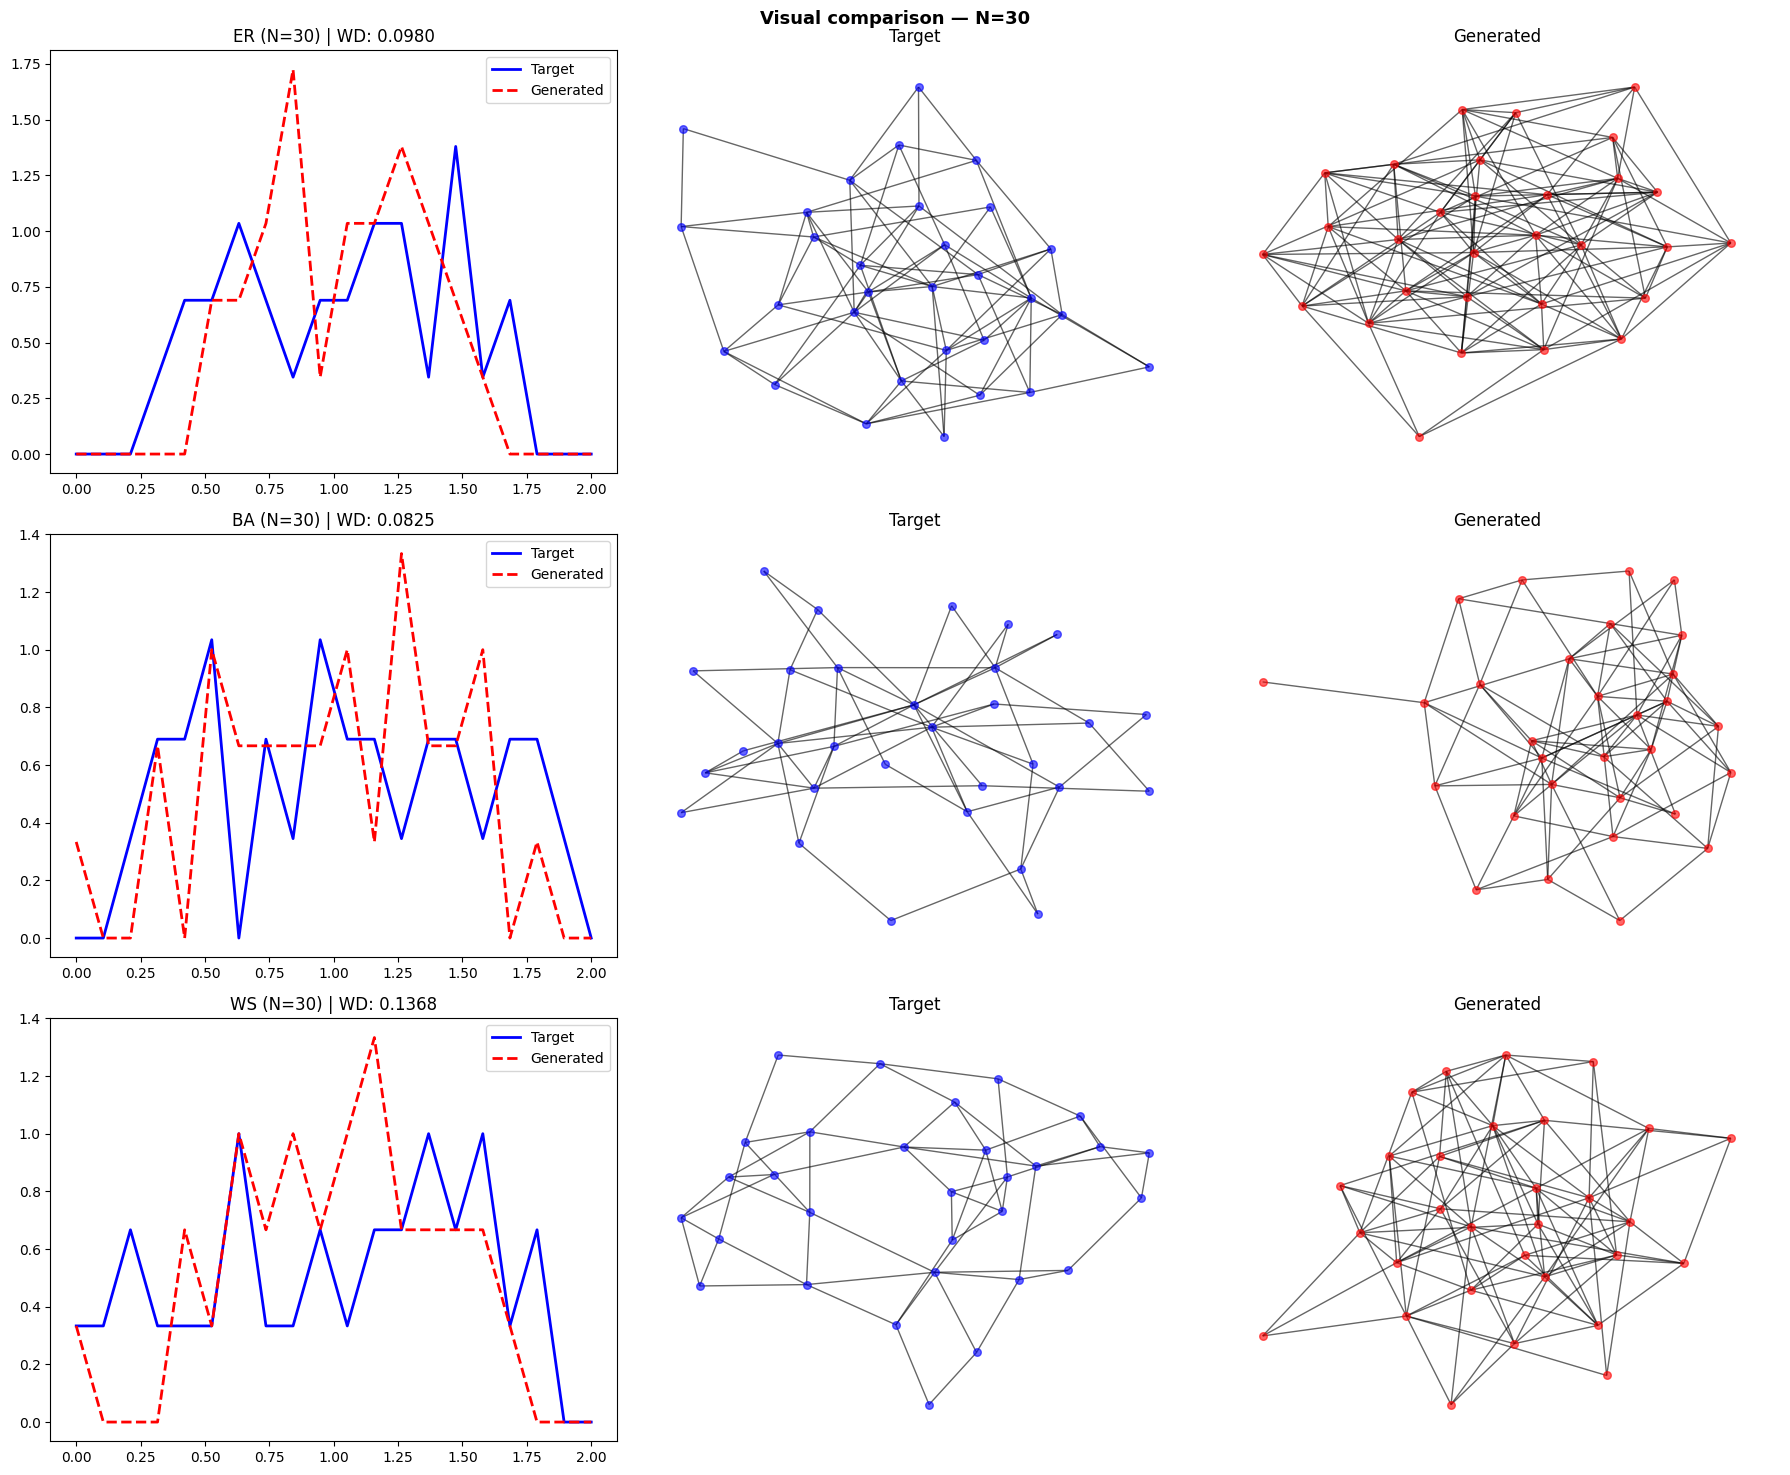

Visual comparison — N=15...


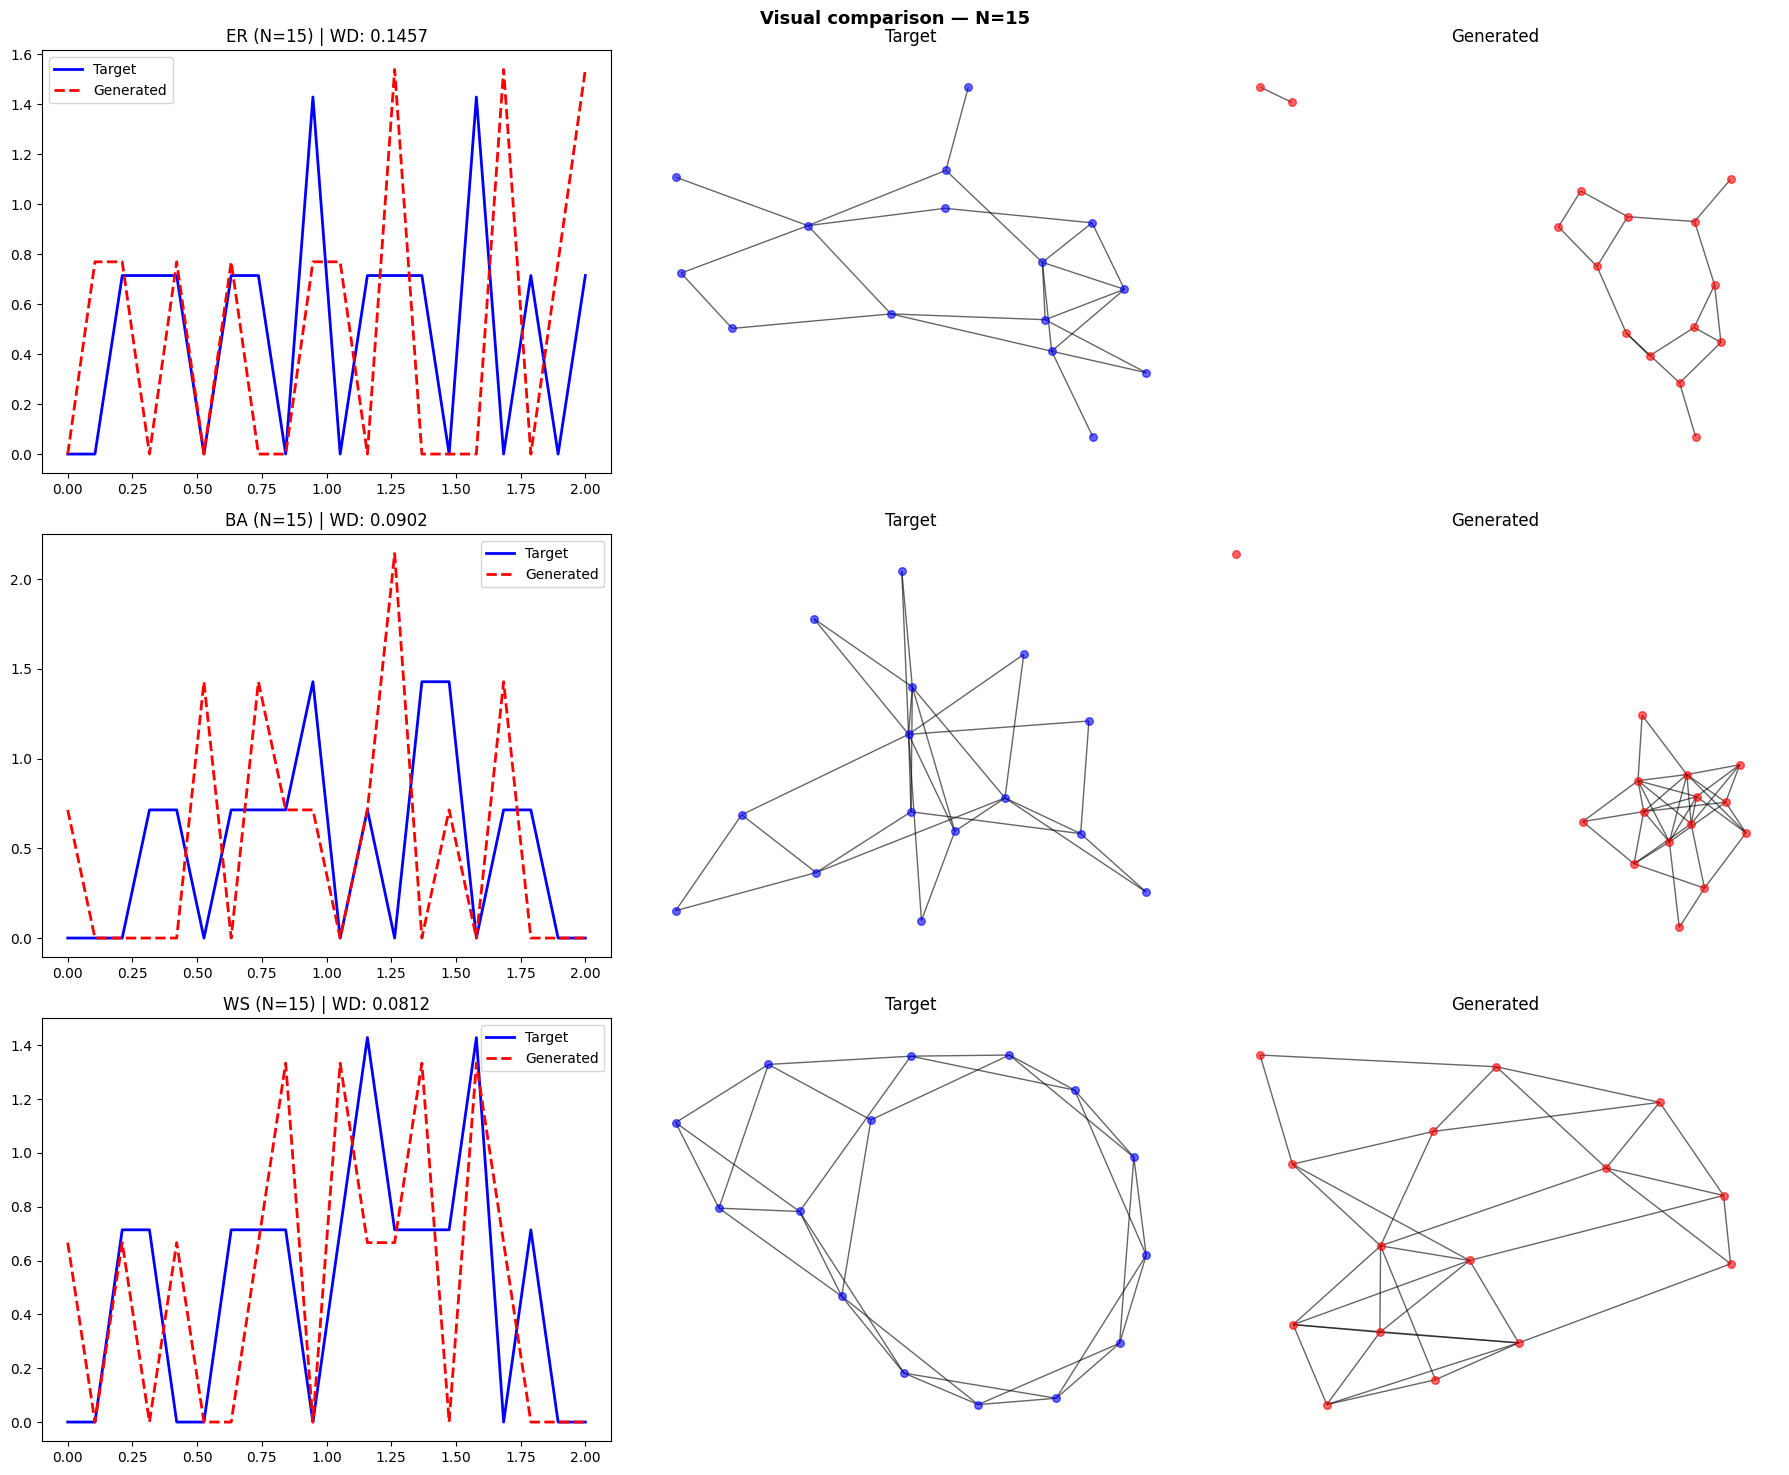

Cross-size visual — target N=30 → generated N=15...


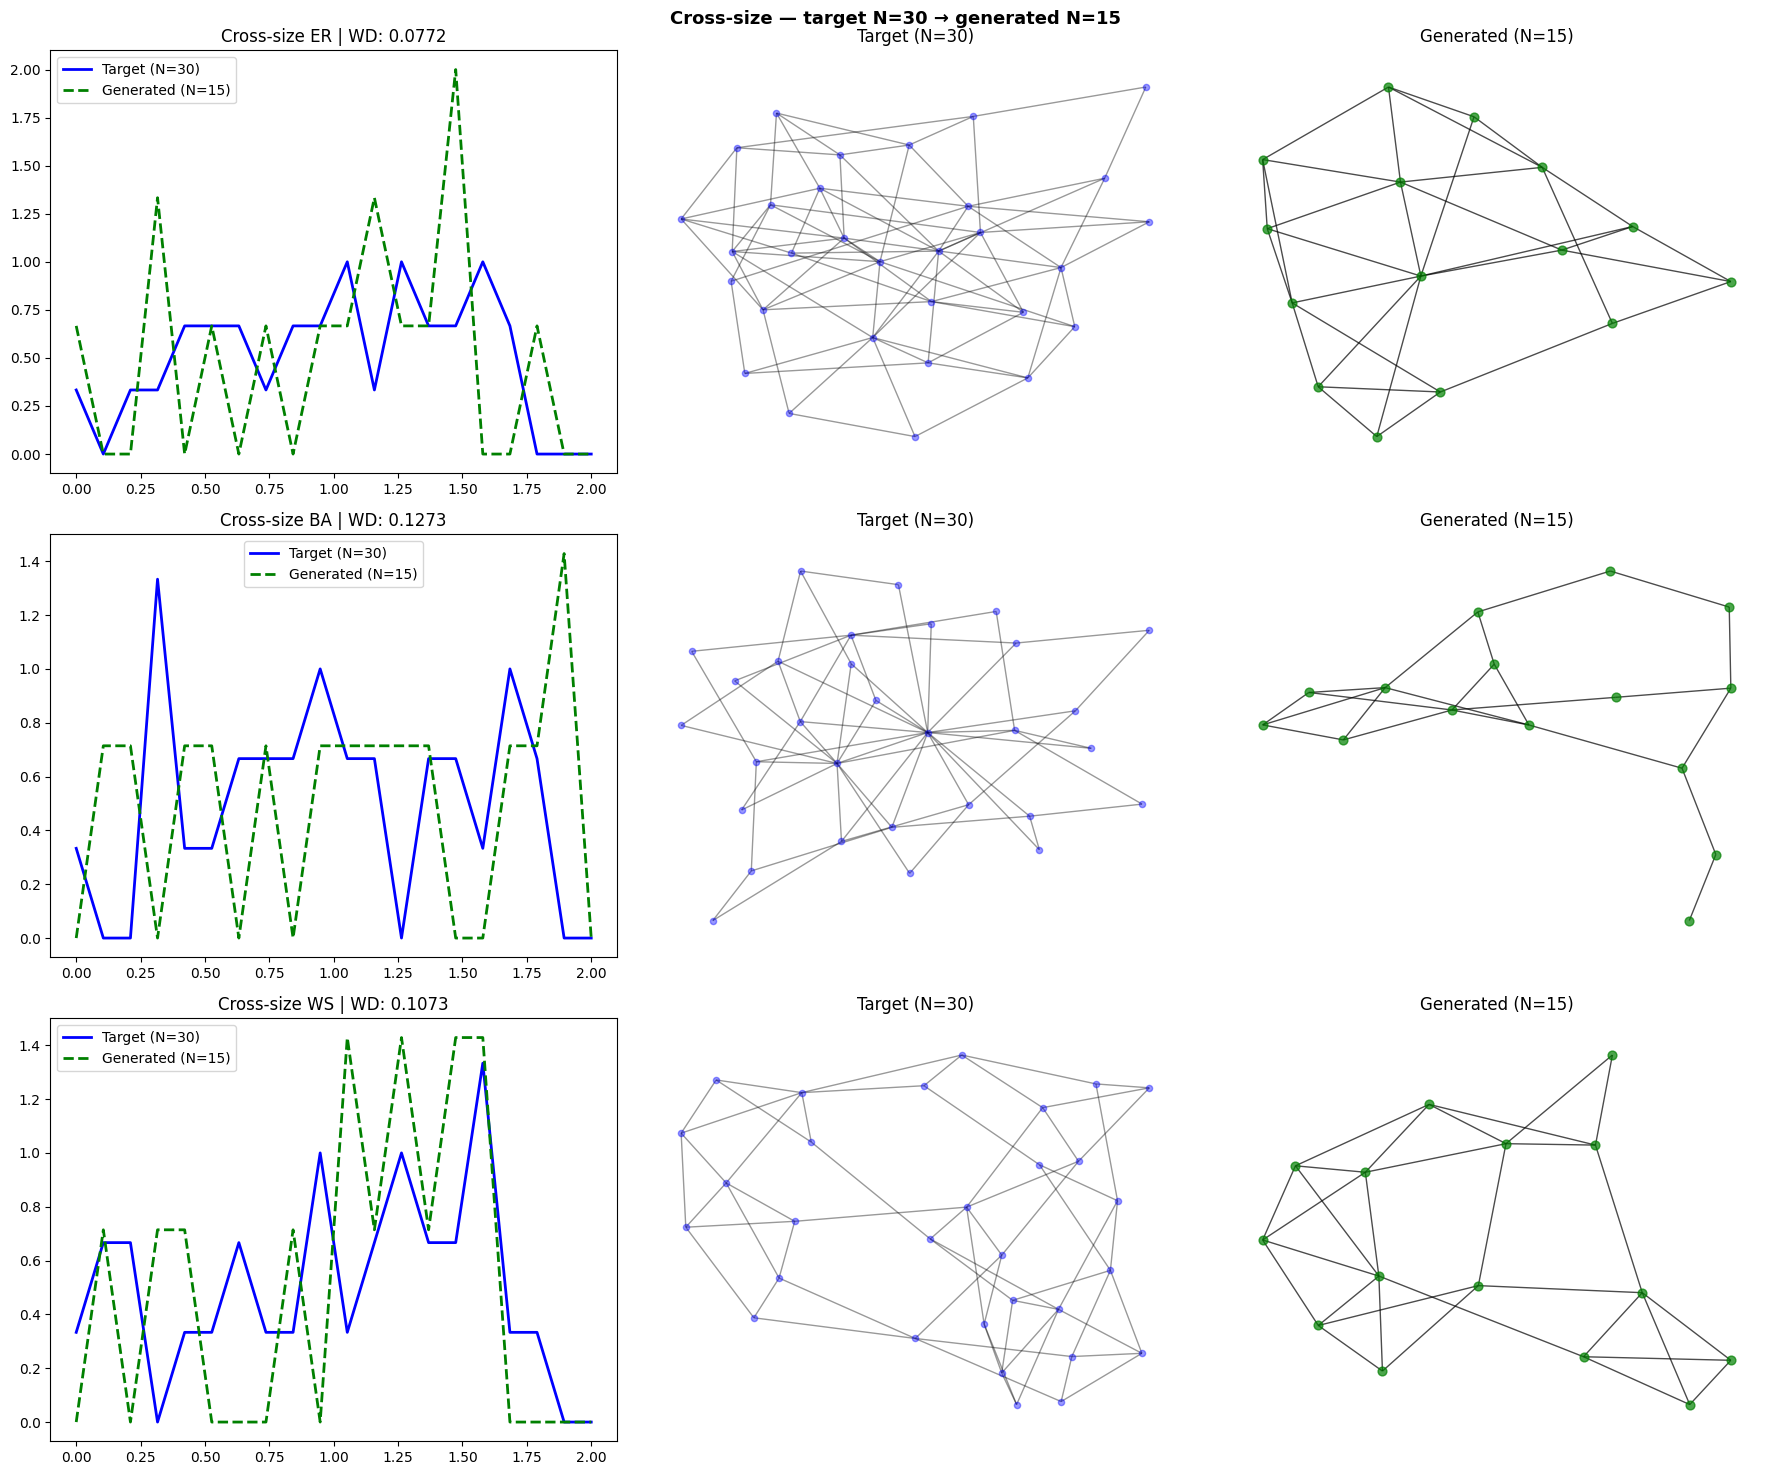

Statistical benchmark — 60 samples...
Using 50 baseline draws per target graph...


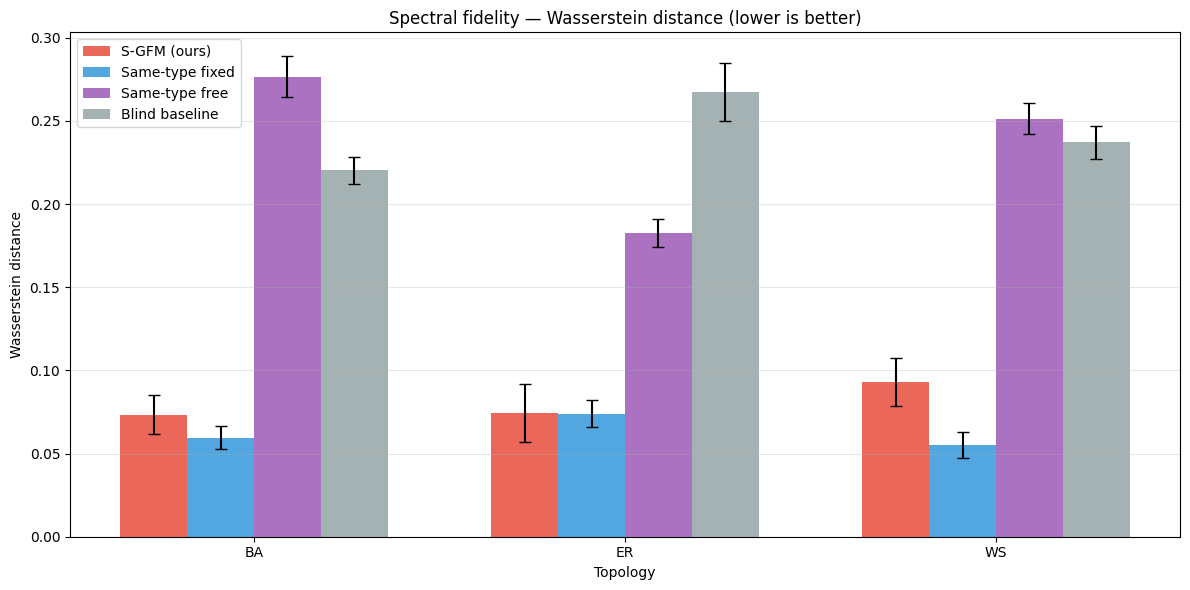

Cross-size statistical benchmark — 60 samples...
Using 50 baseline draws per target graph...


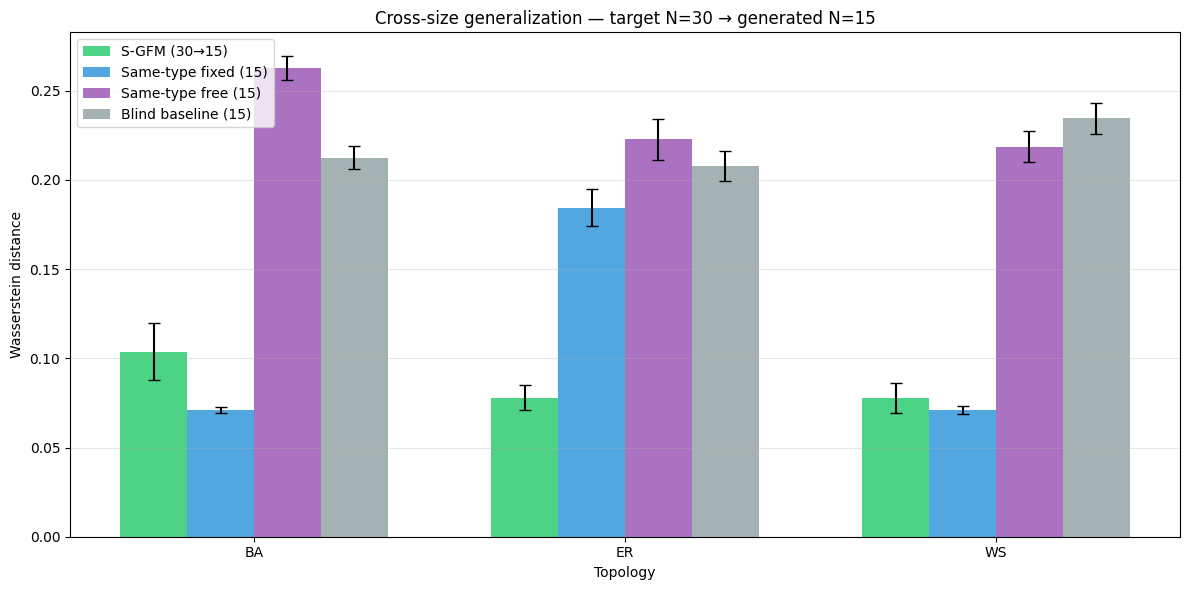

In [ ]:
# ── Quick Visual Sanity Check ──────────────────────────────────────
import igraph as ig

CROSS_ORIG = 30
CROSS_GEN  = 15

def mean_baseline_wd(target_hist, topo, size, params=None, n_trials=20):
    params = params or {}
    wds = []
    for _ in range(n_trials):
        G, _ = random_graph(topo, size, **params)
        h = spectral_histogram(nx.to_numpy_array(G))
        wds.append(spectral_wasserstein(target_hist, h))
    return float(np.mean(wds))


def mean_blind_wd(target_hist, true_topo, size, topologies=('er', 'ba', 'ws'), n_trials=20):
    other_topos = [t for t in topologies if t != true_topo]
    wds = []
    for _ in range(n_trials):
        blind = np.random.choice(other_topos)
        G, _ = random_graph(blind, size)
        h = spectral_histogram(nx.to_numpy_array(G))
        wds.append(spectral_wasserstein(target_hist, h))
    return float(np.mean(wds))

def plot_grouped_bars_with_ci(df, title, ylabel="Wasserstein distance", colors=None):
    means = df.groupby("Topology").mean(numeric_only=True)
    stds  = df.groupby("Topology").std(numeric_only=True).fillna(0.0)
    counts = df.groupby("Topology").size()

    cis = stds.copy()
    for topo in means.index:
        cis.loc[topo] = 1.96 * stds.loc[topo] / np.sqrt(counts.loc[topo])

    x = np.arange(len(means.index))
    cols = list(means.columns)
    n_bars = len(cols)
    width = 0.18 if n_bars == 4 else 0.22

    if colors is None:
        colors = ['#e74c3c', '#3498db', '#9b59b6', '#95a5a6'][:n_bars]

    fig, ax = plt.subplots(figsize=(12, 6))

    for i, col in enumerate(cols):
        offset = (i - (n_bars - 1) / 2) * width
        ax.bar(
            x + offset,
            means[col].values,
            width=width,
            yerr=cis[col].values,
            capsize=4,
            color=colors[i],
            alpha=0.85,
            label=col,
            error_kw={"elinewidth": 1.5}
        )

    ax.set_xticks(x)
    ax.set_xticklabels(means.index)
    ax.set_title(title)
    ax.set_xlabel("Topology")
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

def run_quick_eval(model, topologies=['er', 'ba', 'ws'], n_stat=50, baseline_trials=20):
    bin_centers = np.linspace(0, 2, 20)

    # --- PHASE 1 & 2: Visual comparison at 100 and 50 ---
    for size in [CROSS_ORIG, CROSS_GEN]:
        print(f"Visual comparison — N={size}...")
        fig, axes = plt.subplots(len(topologies), 3, figsize=(18, 5 * len(topologies)))
        for i, topo in enumerate(topologies):
            G_target, _ = random_graph(topo, size, **TEST_PARAMS.get(topo, {}))
            h_target = spectral_histogram(nx.to_numpy_array(G_target))
            gen_adj  = generate_graph_euler(model,
                           torch.tensor(h_target, dtype=torch.float32), size, steps=50)
            h_gen = spectral_histogram(gen_adj[:size, :size])
            wd    = spectral_wasserstein(h_target, h_gen)

            axes[i, 0].plot(bin_centers, h_target, label='Target', color='blue', lw=2)
            axes[i, 0].plot(bin_centers, h_gen, label='Generated', color='red',
                            linestyle='--', lw=2)
            axes[i, 0].set_title(f'{topo.upper()} (N={size}) | WD: {wd:.4f}')
            axes[i, 0].legend()
            nx.draw(G_target, ax=axes[i, 1], node_size=30, node_color='blue', alpha=0.6)
            axes[i, 1].set_title('Target')
            nx.draw(nx.from_numpy_array(gen_adj[:size, :size]),
                    ax=axes[i, 2], node_size=30, node_color='red', alpha=0.6)
            axes[i, 2].set_title('Generated')
        plt.suptitle(f'Visual comparison — N={size}', fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

    # --- PHASE 3: Cross-size visual (100 → 50) ---
    print(f"Cross-size visual — target N={CROSS_ORIG} → generated N={CROSS_GEN}...")
    fig, axes = plt.subplots(len(topologies), 3, figsize=(18, 5 * len(topologies)))
    for i, topo in enumerate(topologies):
        G_orig, _ = random_graph(topo, CROSS_ORIG, **TEST_PARAMS.get(topo, {}))
        h_orig   = spectral_histogram(nx.to_numpy_array(G_orig))
        gen_adj  = generate_graph_euler(model,
                       torch.tensor(h_orig, dtype=torch.float32), CROSS_GEN, steps=50)
        h_gen    = spectral_histogram(gen_adj[:CROSS_GEN, :CROSS_GEN])
        wd       = spectral_wasserstein(h_orig, h_gen)

        axes[i, 0].plot(bin_centers, h_orig, label=f'Target (N={CROSS_ORIG})', color='blue', lw=2)
        axes[i, 0].plot(bin_centers, h_gen, label=f'Generated (N={CROSS_GEN})', color='green',
                        linestyle='--', lw=2)
        axes[i, 0].set_title(f'Cross-size {topo.upper()} | WD: {wd:.4f}')
        axes[i, 0].legend()
        nx.draw(G_orig, ax=axes[i, 1], node_size=20, node_color='blue', alpha=0.4)
        axes[i, 1].set_title(f'Target (N={CROSS_ORIG})')
        nx.draw(nx.from_numpy_array(gen_adj[:CROSS_GEN, :CROSS_GEN]),
                ax=axes[i, 2], node_size=40, node_color='green', alpha=0.7)
        axes[i, 2].set_title(f'Generated (N={CROSS_GEN})')
    plt.suptitle(f'Cross-size — target N={CROSS_ORIG} → generated N={CROSS_GEN}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # --- PHASE 4: Statistical benchmark (same size) ---
    print(f"Statistical benchmark — {n_stat} samples...")
    print(f"Using {baseline_trials} baseline draws per target graph...")
    stats_results = []
    for _ in range(n_stat):
        topo = np.random.choice(topologies)
        size = np.random.randint(MIN_NODES_A, MAX_NODES_A + 1)

        # Target graph uses fixed test params
        G, _ = random_graph(topo, size, **TEST_PARAMS.get(topo, {}))
        h = spectral_histogram(nx.to_numpy_array(G))

        # Our model
        gen_adj = generate_graph_euler(
            model,
            torch.tensor(h, dtype=torch.float32),
            size,
            steps=30
        )
        wd_model = spectral_wasserstein(h, spectral_histogram(gen_adj[:size, :size]))

        # Baselines = average over multiple random draws
        wd_same_fixed = mean_baseline_wd(
            h, topo, size,
            params=TEST_PARAMS.get(topo, {}),
            n_trials=baseline_trials
        )

        wd_same_free = mean_baseline_wd(
            h, topo, size,
            params={},
            n_trials=baseline_trials
        )

        wd_blind = mean_blind_wd(
            h, topo, size,
            topologies=topologies,
            n_trials=baseline_trials
        )

        stats_results.append({
            'Topology': topo.upper(),
            'S-GFM (ours)': wd_model,
            'Same-type fixed': wd_same_fixed,
            'Same-type free': wd_same_free,
            'Blind baseline': wd_blind,
        })

    df_stats = pd.DataFrame(stats_results)
    plot_grouped_bars_with_ci(
        df_stats,
        title='Spectral fidelity — Wasserstein distance (lower is better)',
        ylabel='Wasserstein distance',
        colors=['#e74c3c', '#3498db', '#9b59b6', '#95a5a6']
    )

    # --- PHASE 5: Statistical benchmark (cross-size 100 → 50) ---
    print(f"Cross-size statistical benchmark — {n_stat} samples...")
    print(f"Using {baseline_trials} baseline draws per target graph...")
    cross_results = []
    for _ in range(n_stat):
        topo = np.random.choice(topologies)

        # Target graph at original size uses fixed test params
        G_orig, _ = random_graph(topo, CROSS_ORIG, **TEST_PARAMS.get(topo, {}))
        h_orig = spectral_histogram(nx.to_numpy_array(G_orig))

        # Our model at smaller size
        gen_adj = generate_graph_euler(
            model,
            torch.tensor(h_orig, dtype=torch.float32),
            CROSS_GEN,
            steps=30
        )
        wd_model = spectral_wasserstein(
            h_orig,
            spectral_histogram(gen_adj[:CROSS_GEN, :CROSS_GEN])
        )

        # Baselines at generated size = average over multiple draws
        wd_same_fixed = mean_baseline_wd(
            h_orig, topo, CROSS_GEN,
            params=TEST_PARAMS.get(topo, {}),
            n_trials=baseline_trials
        )

        wd_same_free = mean_baseline_wd(
            h_orig, topo, CROSS_GEN,
            params={},
            n_trials=baseline_trials
        )

        wd_blind = mean_blind_wd(
            h_orig, topo, CROSS_GEN,
            topologies=topologies,
            n_trials=baseline_trials
        )

        cross_results.append({
            'Topology': topo.upper(),
            f'S-GFM ({CROSS_ORIG}→{CROSS_GEN})': wd_model,
            f'Same-type fixed ({CROSS_GEN})': wd_same_fixed,
            f'Same-type free ({CROSS_GEN})': wd_same_free,
            f'Blind baseline ({CROSS_GEN})': wd_blind,
        })

    df_cross = pd.DataFrame(cross_results)
    plot_grouped_bars_with_ci(
        df_cross,
        title=f'Cross-size generalization — target N={CROSS_ORIG} → generated N={CROSS_GEN}',
        ylabel='Wasserstein distance',
        colors=['#2ecc71', '#3498db', '#9b59b6', '#95a5a6']
    )

run_quick_eval(model_a, n_stat=60, baseline_trials=50)

### Model A · Test 1: original 100 → generate 100


######################################################################
  Qualitative demo | 30 → 30
  original N=30  →  generated N=30
######################################################################

Phase 1: Graph generation & metrics …

  ER | original N=30 → generate N=30
  True params: {'p': 0.2}
  Generating graphs …
  Computing graph metrics …


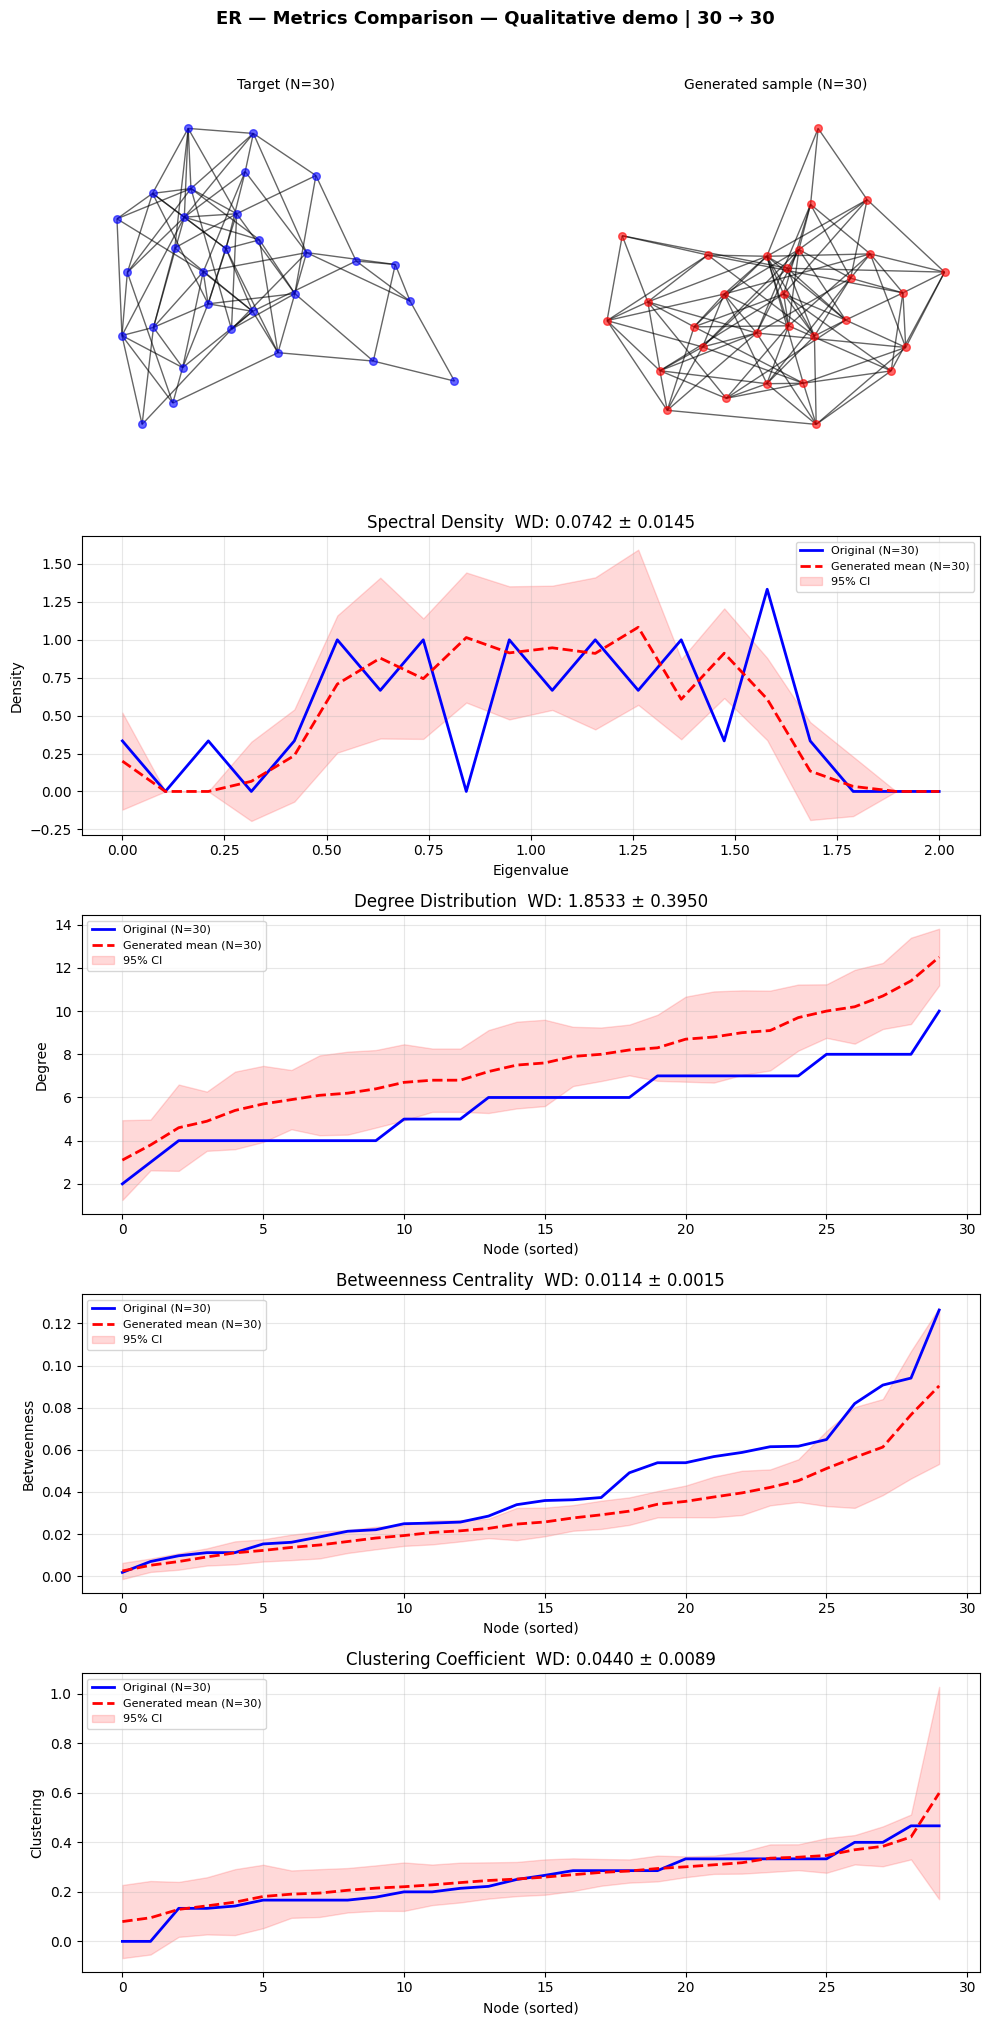


  BA | original N=30 → generate N=30
  True params: {'m': 2, 'power': 1.0}
  Generating graphs …
  Computing graph metrics …


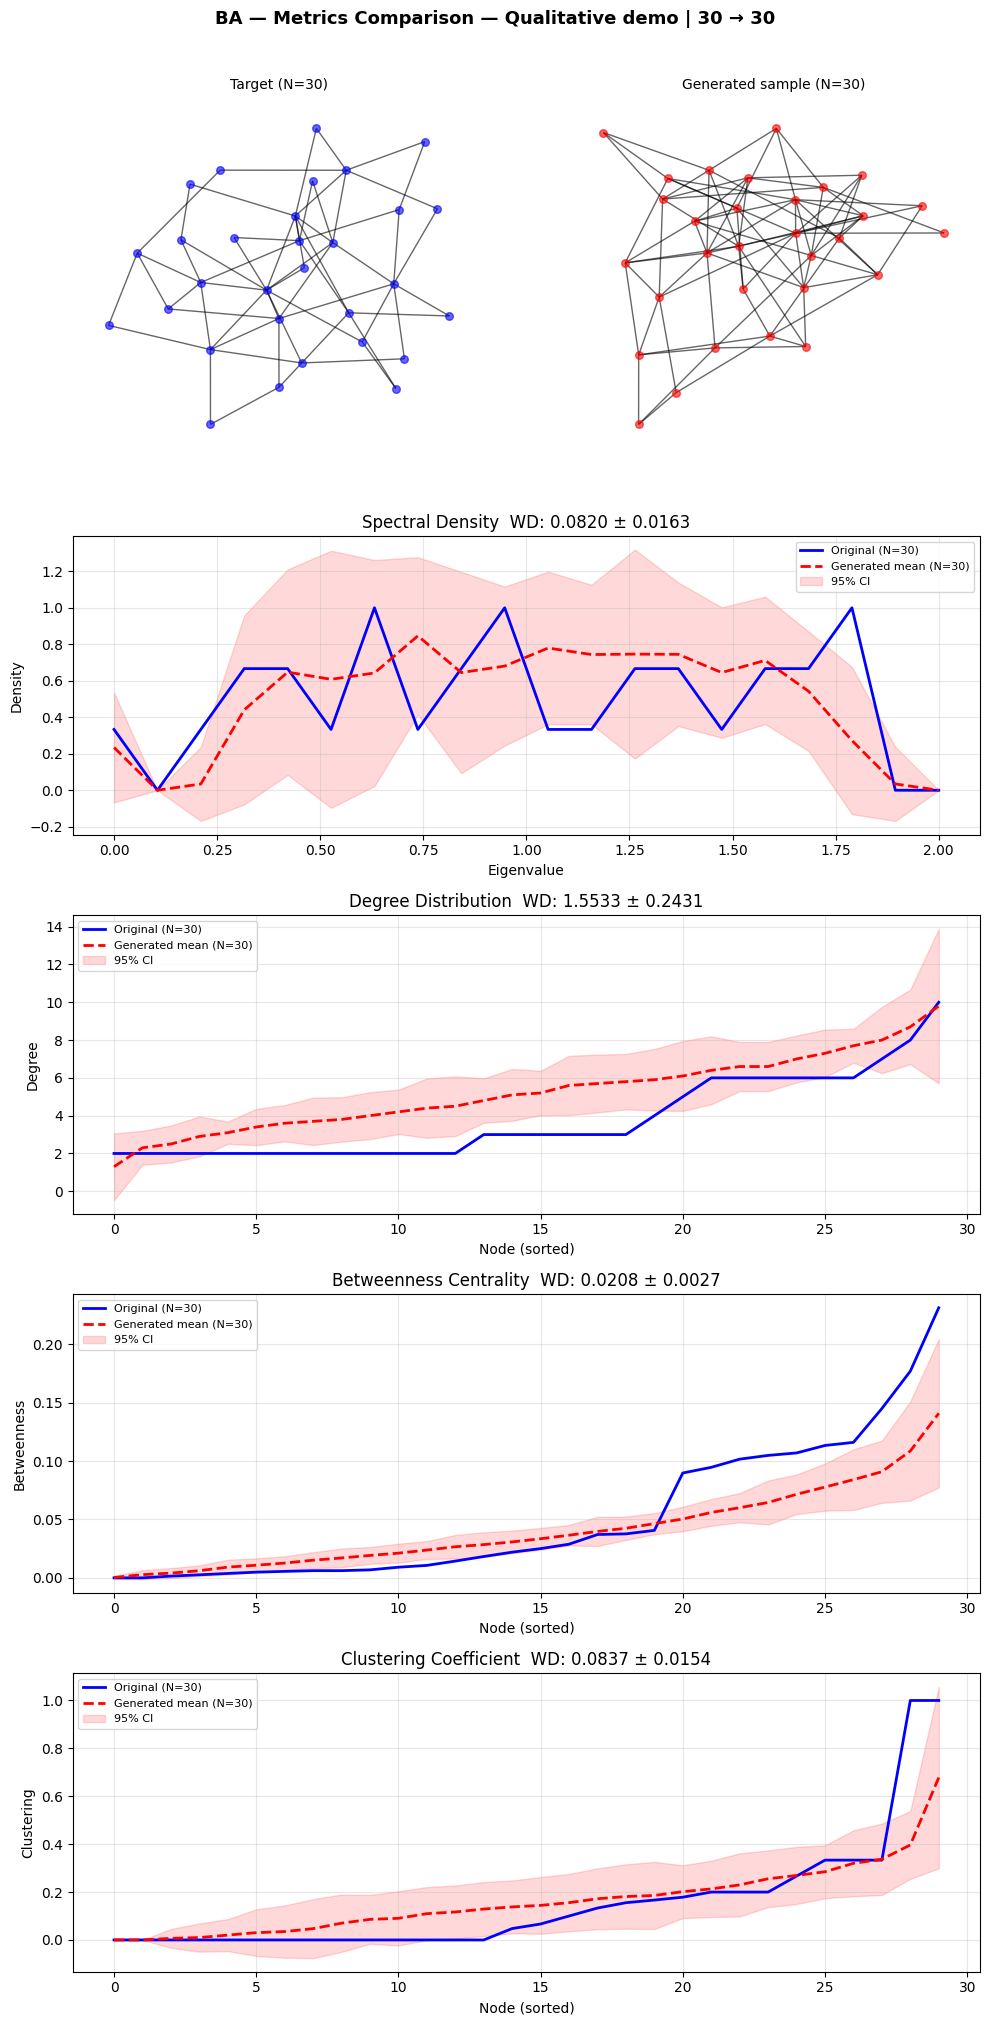


  WS | original N=30 → generate N=30
  True params: {'k': 4, 'p': 0.2}
  Generating graphs …
  Computing graph metrics …


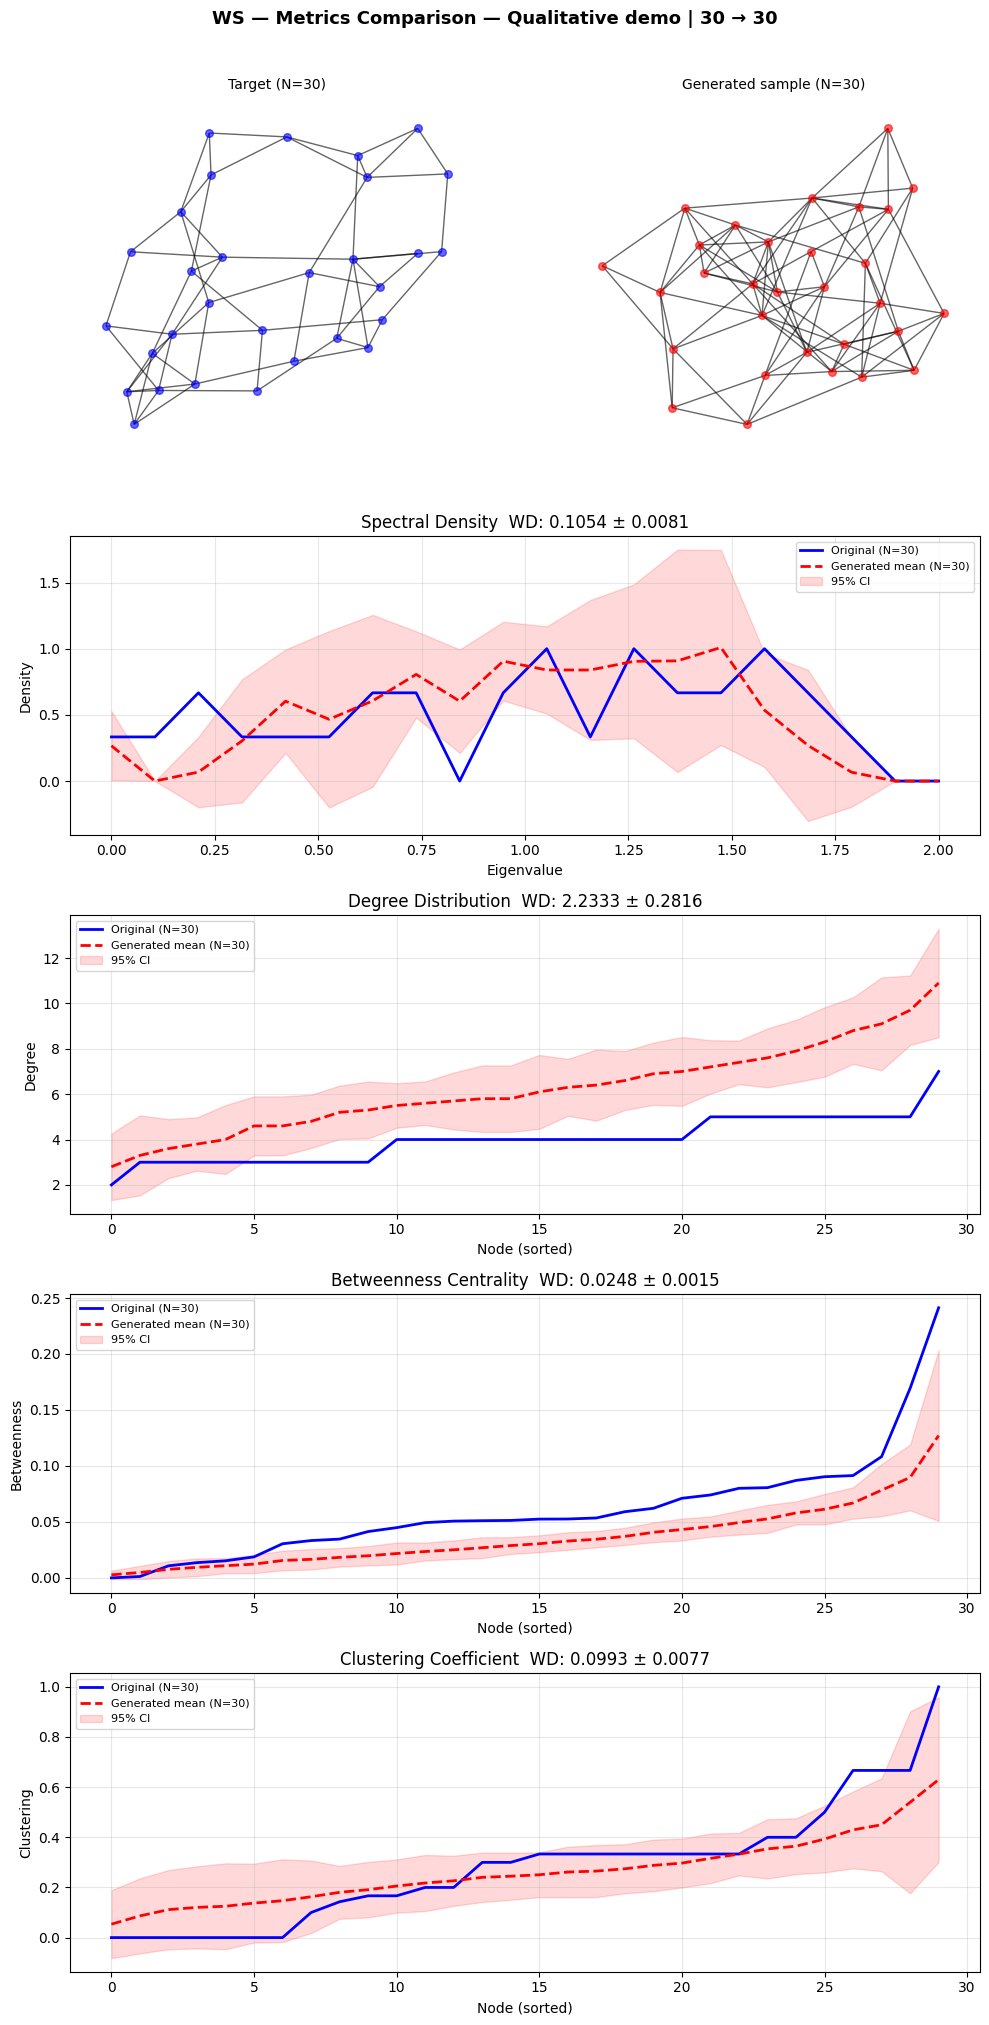


Phase 2: R parameter estimation …
  ER …
  statGraph estimation WITH hint (single batch) …
  orig hint: {'model': 'ER', 'param': 0.2, 'dist': 0.0049, 'error': ''}
  statGraph estimation WITHOUT hint (single batch) …
  orig no hint: {'model': 'WS', 'param': 0.3, 'dist': 0.0014, 'error': ''}
{'model': 'ER', 'param': 0.2, 'dist': 0.0049, 'error': ''}
[{'model': 'ER', 'param': 0.25, 'dist': 0.0042, 'error': ''}, {'model': 'ER', 'param': 0.3, 'dist': 0.0049, 'error': ''}, {'model': 'ER', 'param': 0.25, 'dist': 0.0016, 'error': ''}, {'model': 'ER', 'param': 0.3, 'dist': 0.0052, 'error': ''}, {'model': 'ER', 'param': 0.25, 'dist': 0.0054, 'error': ''}]


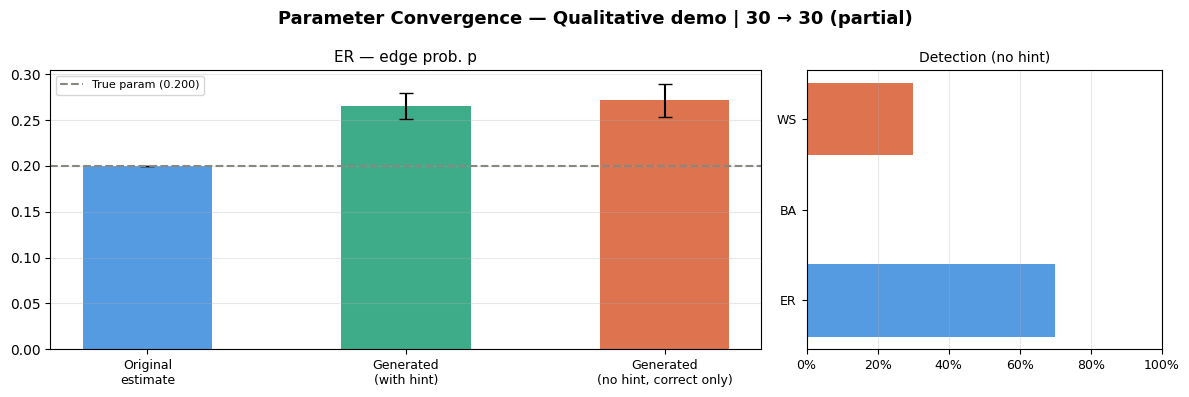

  BA …
  statGraph estimation WITH hint (single batch) …
  orig hint: {'model': 'BA', 'param': 0.4, 'dist': 0.0005, 'error': ''}
  statGraph estimation WITHOUT hint (single batch) …
  orig no hint: {'model': 'BA', 'param': 0.3, 'dist': 0.0007, 'error': ''}
{'model': 'BA', 'param': 0.4, 'dist': 0.0005, 'error': ''}
[{'model': 'BA', 'param': 0.05, 'dist': 0.0044, 'error': ''}, {'model': 'BA', 'param': 0.15, 'dist': 0.0162, 'error': ''}, {'model': 'BA', 'param': 1e-06, 'dist': 0.0052, 'error': ''}, {'model': 'BA', 'param': 0.05, 'dist': 0.0052, 'error': ''}, {'model': 'BA', 'param': 1e-06, 'dist': 0.0029, 'error': ''}]


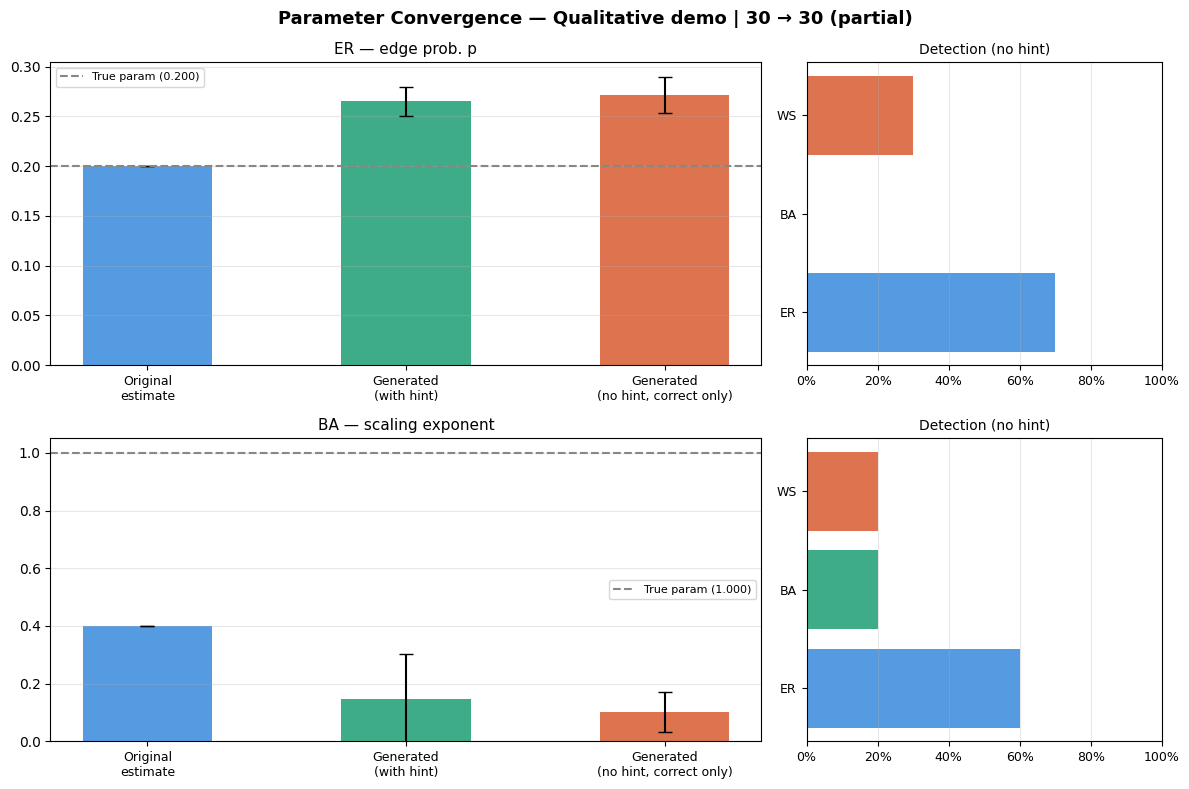

  WS …
  statGraph estimation WITH hint (single batch) …
  orig hint: {'model': 'WS', 'param': 0.15, 'dist': 0.0006, 'error': ''}
  statGraph estimation WITHOUT hint (single batch) …
  orig no hint: {'model': 'WS', 'param': 0.15, 'dist': 0.0004, 'error': ''}
{'model': 'WS', 'param': 0.15, 'dist': 0.0006, 'error': ''}
[{'model': 'WS', 'param': 0.15, 'dist': 0.0244, 'error': ''}, {'model': 'WS', 'param': 0.2, 'dist': 0.0023, 'error': ''}, {'model': 'WS', 'param': 0.8, 'dist': 0.001, 'error': ''}, {'model': 'WS', 'param': 0.8, 'dist': 0.0025, 'error': ''}, {'model': 'WS', 'param': 0.25, 'dist': 0.0069, 'error': ''}]


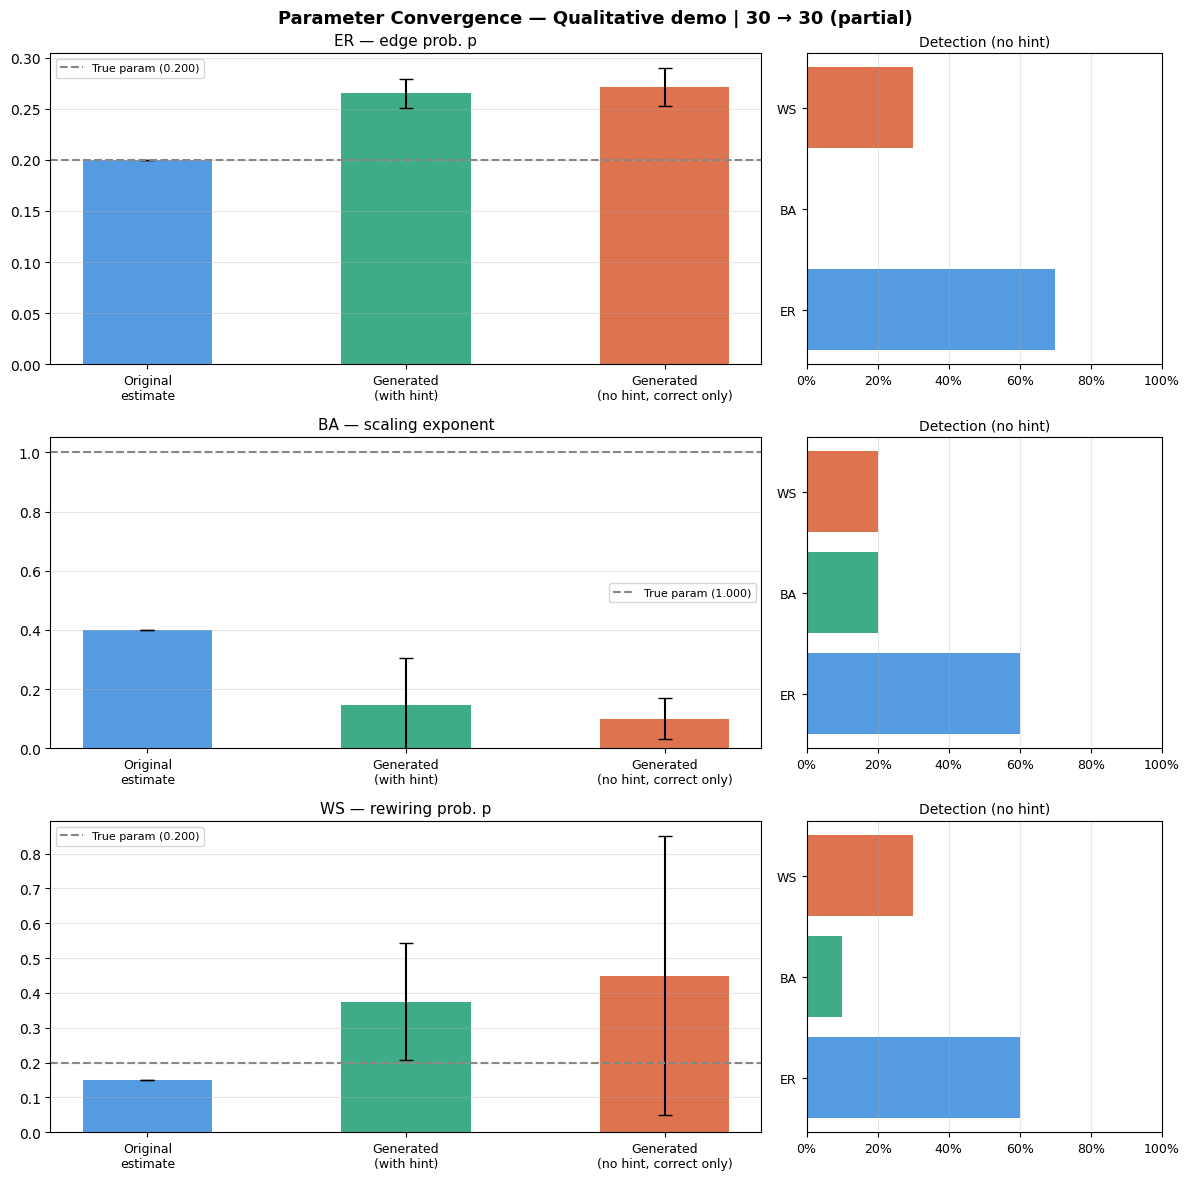

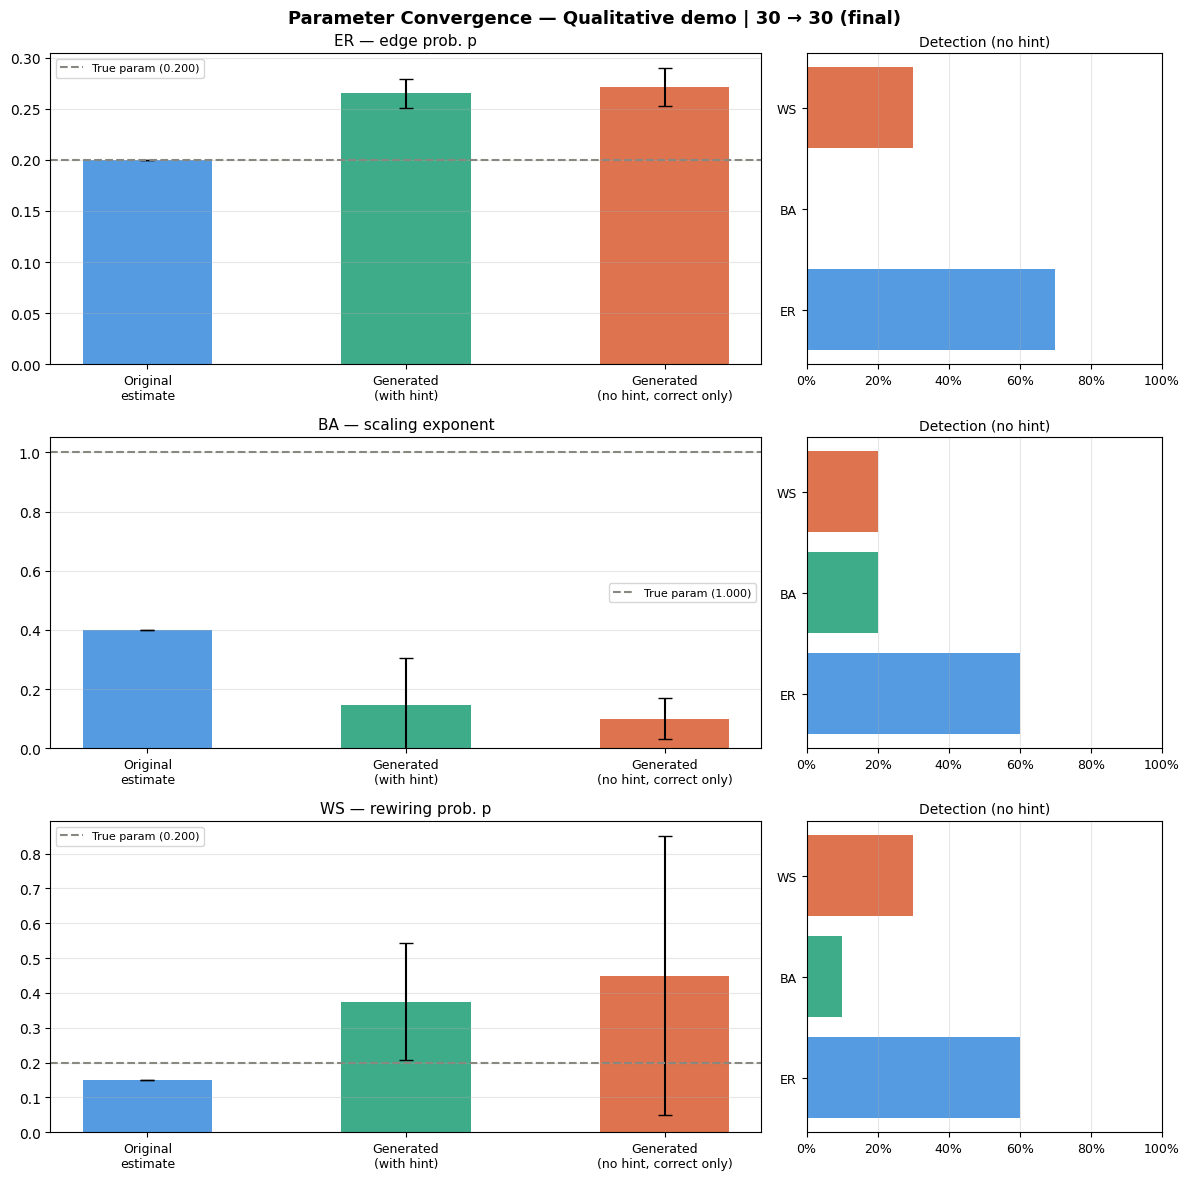

In [ ]:
if RUN_QUALITATIVE_DEMO:
    demo_results = run_full_test(
        model_a,
        "Qualitative demo | 30 → 30",
        orig_size=MAX_NODES_A,
        gen_size=MAX_NODES_A,
        n_gen=10,
        steps=50
    )


Running MANY-TARGET experiment (20 targets per family)…

Model A | 30 → 30 | ER | 3 target graphs

  ER | original N=30 → generate N=30
  True params: {'p': 0.2}
  Generating graphs …
  Computing graph metrics …
  statGraph estimation WITH hint (single batch) …
  orig hint: {'model': 'ER', 'param': 0.2, 'dist': 0.0024, 'error': ''}
  statGraph estimation WITHOUT hint (single batch) …
  orig no hint: {'model': 'BA', 'param': 0.05, 'dist': 0.0021, 'error': ''}
  ER target 1/3 done

  ER | original N=30 → generate N=30
  True params: {'p': 0.2}
  Generating graphs …
  Computing graph metrics …
  statGraph estimation WITH hint (single batch) …
  orig hint: {'model': 'ER', 'param': 0.2, 'dist': 0.0019, 'error': ''}
  statGraph estimation WITHOUT hint (single batch) …
  orig no hint: {'model': 'ER', 'param': 0.2, 'dist': 0.0013, 'error': ''}
  ER target 2/3 done

  ER | original N=30 → generate N=30
  True params: {'p': 0.2}
  Generating graphs …
  Computing graph metrics …
  statGraph esti

,Topology,Spectral WD mean (mean),Spectral WD mean (ci95),Degree WD mean (mean),Degree WD mean (ci95),Betweenness WD mean (mean),Betweenness WD mean (ci95),Clustering WD mean (mean),Clustering WD mean (ci95),orig_est_param_hint (mean),orig_est_param_hint (ci95),gen_est_param_hint_mean (mean),gen_est_param_hint_mean (ci95),gen_est_param_no_hint_correct_mean (mean),gen_est_param_no_hint_correct_mean (ci95),no_hint_correct_detection_rate (mean),no_hint_correct_detection_rate (ci95)
0,BA,0.088862,0.036890,2.444444,0.264938,0.027662,0.002038,0.168471,0.026915,1.033333,1.987036e-01,0.044445,0.010889,0.050001,0.000000,0.222222,0.435556
1,ER,0.064610,0.012706,1.918519,0.294694,0.009538,0.001261,0.090548,0.039974,0.200000,3.846727e-17,0.283333,0.018860,0.280556,0.019630,0.888889,0.217778
2,WS,0.121006,0.024072,2.444444,0.349351,0.023654,0.006569,0.119221,0.033523,0.150000,5.658033e-02,0.233333,0.154377,0.179167,0.187833,0.555556,0.576186


Saved summary_many_a1.csv


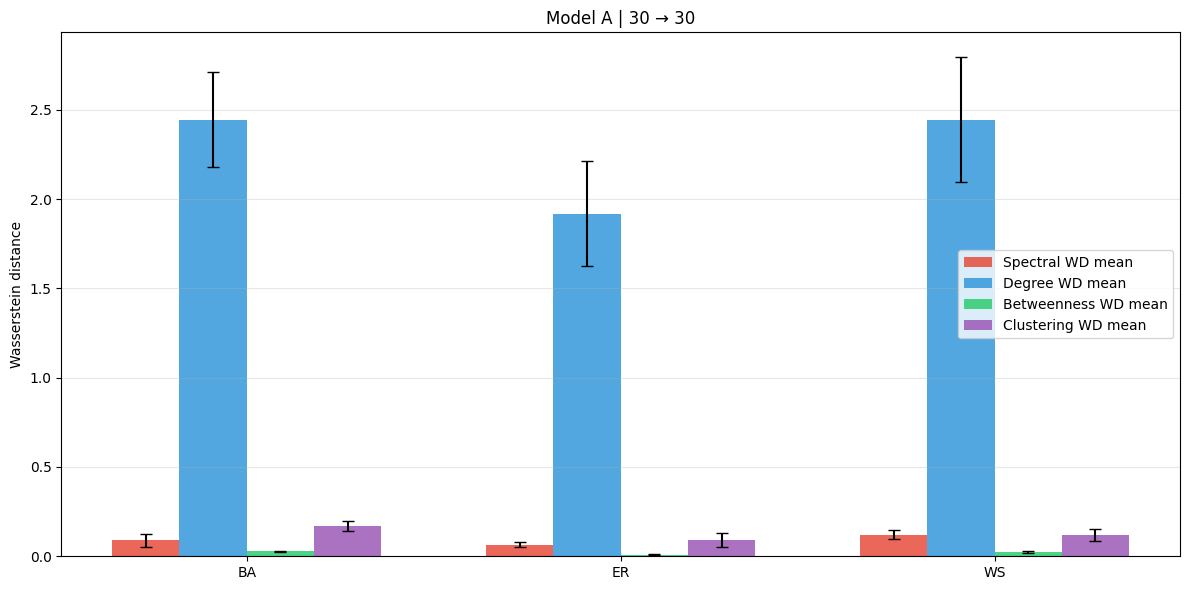

In [ ]:
N_GEN = 3
N_TARGETS = 3

if RUN_MODEL_A_TEST1:
    print("\nRunning MANY-TARGET experiment (20 targets per family)…")

    df_many_a1 = run_many_targets(
        model_a,
        test_label="Model A | 30 → 30",
        orig_size=MAX_NODES_A,
        gen_size=MAX_NODES_A,
        n_targets_per_family=N_TARGETS,
        n_gen=N_GEN,
        steps=50
    )
    df_many_a1.to_csv(RESULTS_DIR + "many_targets_results_a1.csv", index=False)
    print("Saved many_targets_results_a1.csv")

    summary_many_a1 = summarize_many_targets(df_many_a1, label="— Model A | 30 → 30")
    summary_many_a1.to_csv(RESULTS_DIR + "summary_many_a1.csv", index=False)
    print("Saved summary_many_a1.csv")

    plot_many_targets_summary(df_many_a1, title="Model A | 30 → 30")

else:
    print("Skipping Model A Test 1 (RUN_MODEL_A_TEST1=False).")

### Model A · Test 2: original 100 → generate 50


Running MANY-TARGET cross-size experiment (20 targets per family)…

Model A | 30 → 15 | ER | 3 target graphs

  ER | original N=30 → generate N=15
  True params: {'p': 0.2}
  Generating graphs …
  Computing graph metrics …
  statGraph estimation WITH hint (single batch) …
  orig hint: {'model': 'ER', 'param': 0.2, 'dist': 0.0032, 'error': ''}
  statGraph estimation WITHOUT hint (single batch) …
  orig no hint: {'model': 'ER', 'param': 0.2, 'dist': 0.0024, 'error': ''}
  ER target 1/3 done

  ER | original N=30 → generate N=15
  True params: {'p': 0.2}
  Generating graphs …
  Computing graph metrics …
  statGraph estimation WITH hint (single batch) …
  orig hint: {'model': 'ER', 'param': 0.2, 'dist': 0.0018, 'error': ''}
  statGraph estimation WITHOUT hint (single batch) …
  orig no hint: {'model': 'WS', 'param': 0.3, 'dist': 0.0007, 'error': ''}
  ER target 2/3 done

  ER | original N=30 → generate N=15
  True params: {'p': 0.2}
  Generating graphs …
  Computing graph metrics …
  stat

,Topology,Spectral WD mean (mean),Spectral WD mean (ci95),Degree WD mean (mean),Degree WD mean (ci95),Betweenness WD mean (mean),Betweenness WD mean (ci95),Clustering WD mean (mean),Clustering WD mean (ci95),orig_est_param_hint (mean),orig_est_param_hint (ci95),gen_est_param_hint_mean (mean),gen_est_param_hint_mean (ci95),gen_est_param_no_hint_correct_mean (mean),gen_est_param_no_hint_correct_mean (ci95),no_hint_correct_detection_rate (mean),no_hint_correct_detection_rate (ci95)
0,BA,0.105284,0.022291,0.903704,0.233653,0.063901,0.025229,0.113658,0.065296,0.783333,3.457115e-01,0.555556,0.348954,0.675000,0.102002,0.444444,0.217778
1,ER,0.076319,0.005987,1.125926,0.233653,0.021172,0.002955,0.168428,0.104852,0.216667,3.266667e-02,0.372222,0.028809,0.325000,0.000000,0.222222,0.435556
2,WS,0.084858,0.022969,0.407407,0.014519,0.041117,0.014208,0.234727,0.075633,0.100000,1.923363e-17,0.066667,0.068001,0.061111,0.057619,1.000000,0.000000


Saved summary_many_a2.csv


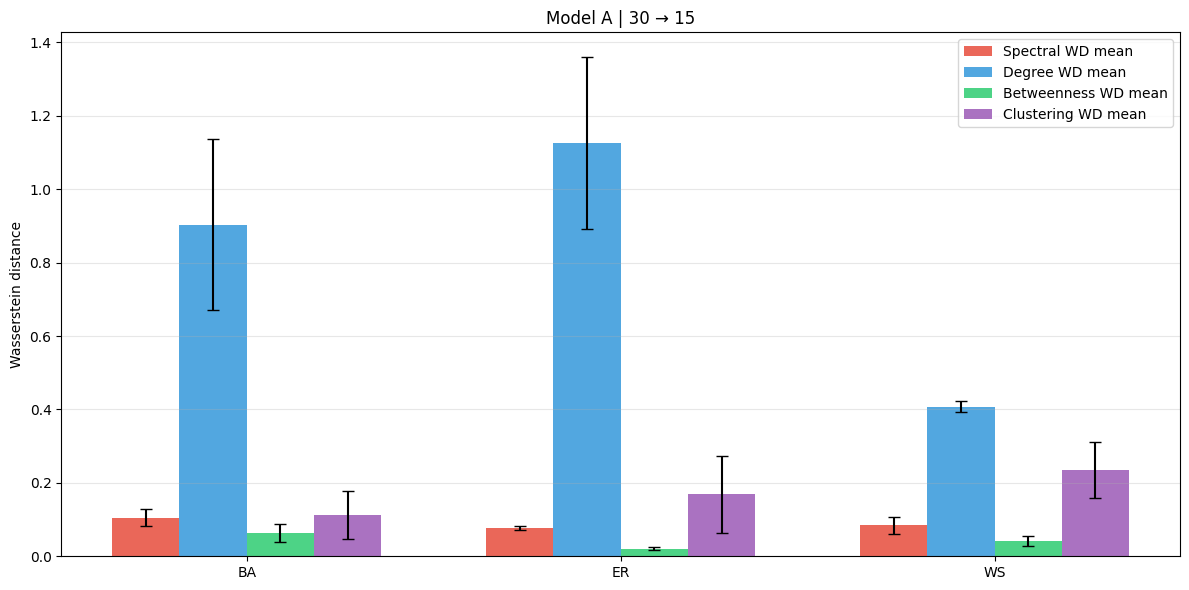

In [ ]:
if RUN_MODEL_A_TEST2:
    print("\nRunning MANY-TARGET cross-size experiment (20 targets per family)…")

    df_many_a2 = run_many_targets(
        model_a,
        test_label="Model A | 30 → 15",
        orig_size=MAX_NODES_A,
        gen_size=MIN_NODES_A,
        n_targets_per_family=N_TARGETS,
        n_gen=N_GEN,
        steps=50
    )
    df_many_a2.to_csv(RESULTS_DIR + "many_targets_results_a2.csv", index=False)
    print("Saved many_targets_results_a2.csv")

    summary_many_a2 = summarize_many_targets(df_many_a2, label="— Model A | 30 → 15")
    summary_many_a2.to_csv(RESULTS_DIR + "summary_many_a2.csv", index=False)
    print("Saved summary_many_a2.csv")

    plot_many_targets_summary(df_many_a2, title="Model A | 30 → 15")

else:
    print("Skipping Model A Test 2 (RUN_MODEL_A_TEST2=False).")

---
## Model B — `max_nodes=200`, permutation augmentation

Train on graphs of 20–100 nodes, but scatter node positions randomly across
all 200 slots so no positions are always zero.

**Test:** degradation curve — generate graphs at sizes 50, 75, 100, 110, 125,
140, 160, 180, 200 and plot mean spectral Wasserstein distance vs. graph size.
Sizes ≤ 100 are sanity checks; sizes > 100 are the extrapolation regime.


In [ ]:
MAX_NODES_B_MODEL = 60
MAX_NODES_B_DATA = 30
MIN_NODES_B = 15

if LOAD_MODELS_FROM_DRIVE and os.path.exists(MODEL_B_PATH):
    print(f"Loading Model B from {MODEL_B_PATH} …")
    model_b = VelocityFieldMLP(max_nodes=MAX_NODES_B_MODEL, hidden_dim=HIDDEN_DIM)
    model_b.load_state_dict(torch.load(MODEL_B_PATH, map_location=DEVICE))
    model_b.to(DEVICE).eval()
    print("Model B loaded.")

    print(f"Loading/generating dataset (max_nodes={MAX_NODES_B_DATA}, permutation) …")
    ds_b, loader_b = generate_graph_data(
        num_graphs=NUM_GRAPHS,
        min_nodes=MIN_NODES_B,
        max_nodes=MAX_NODES_B_DATA,
        use_permutation=True,
        dataset_path=DATASET_B_PATH
    )
else:
    print(f"Generating dataset (max_nodes={MAX_NODES_B_DATA}, permutation augmentation) …")
    ds_b, loader_b = generate_graph_data(
        num_graphs=NUM_GRAPHS,
        min_nodes=MIN_NODES_B,
        max_nodes=MAX_NODES_B_DATA,
        use_permutation=True,
        dataset_path=DATASET_B_PATH
    )
    model_b = VelocityFieldMLP(max_nodes=MAX_NODES_B_MODEL, hidden_dim=HIDDEN_DIM)
    print(f"Parameters: {sum(p.numel() for p in model_b.parameters()):,}")
    train_model(model_b, loader_b, epochs=EPOCHS)
    torch.save(model_b.state_dict(), MODEL_B_PATH)
    print(f"Model B saved to {MODEL_B_PATH}")

Generating dataset (max_nodes=30, permutation augmentation) …
Saving dataset to /content/drive/MyDrive/GFM/dataset_b.pkl …
Saved.
Parameters: 2,387,754
Training 100 epochs on cuda …


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x520 and 1855x512)

### Model B · Degradation Curve

In [ ]:
if RUN_MODEL_B:
    def run_degradation_curve(model, test_sizes, n_per_size=30, steps=50):
        topologies = ["ER", "BA", "WS"]
        per_topo = max(1, n_per_size // len(topologies))
        curve = {}

        for size in test_sizes:
            print(f"  Testing size={size} …", end=" ", flush=True)
            wds = []
            for topo in topologies:
                for _ in range(per_topo):
                    G, _ = random_graph(topo.lower(), size, **TEST_PARAMS.get(topo.lower(), {}))
                    h = spectral_histogram(nx.to_numpy_array(G))
                    adj = generate_graph_euler(
                        model,
                        torch.tensor(h, dtype=torch.float32),
                        size,
                        steps=steps
                    )
                    h_gen = spectral_histogram(adj[:size, :size])
                    wds.append(spectral_wasserstein(h, h_gen))
            curve[size] = wds
            print(f"mean WD={np.mean(wds):.4f}")

        return curve

    TEST_SIZES = [15, 20, 25, 30, 35, 40, 50, 60]
    curve = run_degradation_curve(model_b, TEST_SIZES, n_per_size=15)

    means = [np.mean(curve[s]) for s in TEST_SIZES]
    cis = [1.96 * np.std(curve[s]) / np.sqrt(len(curve[s])) for s in TEST_SIZES]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axvspan(0, 30, alpha=0.07, color="green", label="Training range")
    ax.axvspan(30, max(TEST_SIZES) + 5, alpha=0.07, color="red", label="Extrapolation regime")

    ax.errorbar(
        TEST_SIZES, means, yerr=cis,
        fmt="o-", color="#2c3e50",
        capsize=5, linewidth=2, markersize=7
    )
    ax.axvline(30, color="gray", linestyle="--", linewidth=1.2, label="Training ceiling (N=30)")
    ax.set_xlabel("Generated graph size", fontsize=12)
    ax.set_ylabel("Spectral Wasserstein Distance (mean ± 95% CI)", fontsize=11)
    ax.set_title("Model B — Extrapolation Degradation Curve", fontsize=13, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("Skipping Model B degradation curve (RUN_MODEL_B=False).")